In [201]:
!pip install tensorflow
!pip install scikit-learn
!pip install matplotlib
!pip install keras
!pip install keras_tuner
!pip install gzip
!pip install numpy
!pip install ViennaRNA
!pip install regex
!pip install seaborn
!pip install tensorboard
!pip install xelatex

ERROR: Could not find a version that satisfies the requirement gzip (from versions: none)
ERROR: No matching distribution found for gzip
ERROR: Could not find a version that satisfies the requirement xelatex (from versions: none)
ERROR: No matching distribution found for xelatex


In [1]:
import gzip
import pandas as pd
import numpy as np
import sklearn
import regex as re
import seaborn as sns
import keras as ks
import keras_tuner as kt
import tensorflow 
import csv
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, classification_report, roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Concatenate, Input, GlobalMaxPool1D, GlobalMaxPooling1D
from tensorflow.keras.metrics import Precision, Recall, F1Score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

2026-06-16 20:06:20.378939: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# motif_patterns = {
#     "hairpin": re.compile(r"\({3,}\.{3,}\){3,}"),
#     "bulgeloop": re.compile(r"\({2,}\.{1,}\({2,}\.{3,}\){2,}\){1,}"),
#     "repetitive_hairpin": re.compile(r"(?:\({3,}\.{3,}\){3,}\.{1,}){2,}")
# }
motif_patterns = {
    "hairpin": re.compile(r"\.{3,}\({3,}\.{3,}\){3,}\.{3,}"),
    "bulgeloop": re.compile(r"\.{3,}\({2,}\.{2,}\({1,}\.{3,}\){3,}\.{3,}"),
    "repetitive_hairpin_pattern":re.compile(r"(?:\.{3,}\({3}\.{3}\){3}\.{3,}){2,}")
}

In [3]:
# motif_counts = pd.DataFrame({
#     "motif_id": [f"hairpin_{i+1}" for i in range(12)]
#                 + [f"bulgeloop_{i+1}" for i in range(12)]
#                 + [f"repetitive_hairpin_{i+1}" for i in range(12)],
#     "motif_type": ["hairpin"] * 12
#                   + ["bulgeloop"] * 12
#                   + ["repetitive_hairpin"] * 12,
#     "motif": simple_hairpin
#              + simple_bulgeloop
#              + repetitive_short_hairpins,
#     "n_occurrences": [
#         982, 1080, 1064, 1077, 1116, 636, 359, 90, 19, 15, 4, 3,
#         0, 0, 0, 2, 6, 2, 3, 3, 0, 0, 0, 0,
#         982, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
#     ]
# })

In [4]:
def one_hot_encode(seq, fixlength=500):
    if len(seq) < fixlength:
        seq += "." * (fixlength - len(seq))

    seq = seq[:fixlength]

    mapping = {
        "(": [1, 0, 0],
        ".": [0, 1, 0],
        ")": [0, 0, 1]
    }

    return np.array([mapping[base] for base in seq])

In [ ]:

df = pd.read_csv('ViSiR_GenbankVirus_26.03_1000_selection.tsv', sep='\t', header=0)
print(df.shape)
print(df)

#  Explode the lists into individual rows (tracks original index)
# exploded = df["split_seq"].explode()
# print(exploded)

(20589, 19)
        accession  length    taxid                  host lab_host host_type  \
0        X62493.1    4789    12142                   NaN      NaN   unknown   
1        X16568.1    9207    11234                   NaN      NaN   unknown   
2        X16949.1    2309    28877                   NaN      NaN   unknown   
3        X56019.1    8101    12127                   NaN      NaN   unknown   
4        X02986.1    4003    11986                   NaN      NaN   unknown   
...           ...     ...      ...                   ...      ...       ...   
20584  PX597326.1    7728  2651944         Culex pipiens      NaN   natural   
20585  OZ412855.1   12714   162145                   NaN      NaN   unknown   
20586  BR002566.1    8269  2794431      Persea americana      NaN   natural   
20587  BR002569.1    8276   129141          Prunus avium      NaN   natural   
20588  BR002572.1    8264  2765862  Rhododendron obtusum      NaN   natural   

                 collection_date  \
0  

In [6]:
# df_min = df['Lineage4'].value_counts().min()
# print(df_min)

In [7]:
balanced_df = pd.read_pickle("balanced_lineage_dataset.pkl")

In [8]:
def stem_length(structure):
    return structure.count("(")

def paired_length(structure):
    return min(structure.count("("),structure.count(")"))

def loop_length(structure):
    loops = re.findall(r"\.+", structure)
    if loops:
        return max(len(loop) for loop in loops)
    return 0

def paired_ratio(structure):
    paired = structure.count("(") + structure.count(")")
    return paired / len(structure)

def max_depth(structure):
    depth = 0
    max_d = 0

    for char in structure:

        if char == "(":
            depth += 1
            max_d = max(max_d, depth)

        elif char == ")":
            depth -= 1

    return max_d

def bulge_count(structure):
    count = 0

    for match in re.finditer(r"\.+", structure):
        start, end = match.span()

        left_part = structure[:start]
        right_part = structure[end:]

        has_left_pair = "(" in left_part
        has_right_pair = ")" in right_part

        if has_left_pair and has_right_pair:
            count += 1

    return count

def stem_count(structure):
    stems = re.findall(r"\(+", structure)
    return len(stems)


def repetitive_count(structure):
    unit_pattern = re.compile(r"\({3,}\.{3,}\){3,}")
    return len(unit_pattern.findall(structure))

def count_motif(sequence, motif):
    return sequence.count(motif)

In [9]:
def build_model(hp):
    model = Sequential([
        Conv1D(
            filters = hp.Choice("filter_1", [16, 32, 64, 128]),
            kernel_size = hp.Choice("kernel_1", [3, 5, 8, 12]),
            activation = 'relu',
            input_shape = (1000,3)
        ),
        MaxPooling1D(
            pool_size = hp.Choice("pool_size_1", [2,3,4])        
        ),
        Conv1D(
            filters = hp.Choice("filter_2", [16, 32, 64, 128]),
            kernel_size = hp.Choice("kernel_2", [3, 5, 8, 12]),
            activation = 'relu'
        ),
        MaxPooling1D(
            pool_size = hp.Choice("pool_size_2", [2,3,4])        
        ),
        Flatten(),
        Dense(
            units = hp.Choice("units_1", [16, 32, 64, 128]),
            activation='relu'
        ),
        Dropout(
            rate = hp.Choice("rate", [0.3, 0.5])
        ),
        Dense(
            num_classes, 
            activation="softmax"
        )
        
    ])
    
    model.compile(
        optimizer = Adam(
            learning_rate = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
        ),
        loss = "sparse_categorical_crossentropy",# niet meer binary
        metrics=[
            'accuracy'
            
        ]
    )
    
    return model



In [10]:
def build_fixed_model():
    model = Sequential([
        Conv1D(32, kernel_size=8, activation="relu", input_shape=(1000, 3)),
        MaxPooling1D(pool_size=2),

        Conv1D(16, kernel_size=8, activation="relu"),
        MaxPooling1D(pool_size=2),

        Flatten(),
        Dense(32, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [11]:
import shutil

shutil.rmtree("tuner_results/ViSiR_global_tuning", ignore_errors=True)


In [12]:
def find_all_motifs_in_sequence(fold, all_motifs, motif_types):
    occurrences = []

    for i, (motif, motif_type) in enumerate(zip(all_motifs, motif_types)):
        start = 0

        while True:
            idx = fold.find(motif, start)

            if idx == -1:
                break

            occurrences.append({
                "motif_id": f"motif_{i}",
                "motif": motif,
                "motif_type": motif_type,
                "motif_start": idx,
                "motif_end": idx + len(motif),
                "paired_length": paired_length(motif),
                "sequence_length": len(motif)
            })

            # idx + 1 allows overlapping motifs
            start = idx + 1

    occurrences = sorted(
        occurrences,
        key=lambda x: x["motif_start"]
    )

    return occurrences

In [13]:
def build_model(hp):
    model = Sequential([
        Conv1D(
            filters = hp.Choice("filter_1", [16, 32, 64, 128]),
            kernel_size = hp.Choice("kernel_1", [3, 5, 8, 12]),
            activation = 'relu',
            input_shape = (1000,3)
        ),
        MaxPooling1D(
            pool_size = hp.Choice("pool_size_1", [2,3,4])        
        ),
        Conv1D(
            filters = hp.Choice("filter_2", [16, 32, 64, 128]),
            kernel_size = hp.Choice("kernel_2", [3, 5, 8, 12]),
            activation = 'relu'
        ),
        MaxPooling1D(
            pool_size = hp.Choice("pool_size_2", [2,3,4])        
        ),
        Flatten(),
        Dense(
            units = hp.Choice("units_1", [16, 32, 64, 128]),
            activation='relu'
        ),
        Dropout(
            rate = hp.Choice("rate", [0.3, 0.5])
        ),
        Dense(
            num_classes, 
            activation="softmax"
        )
        
    ])
    
    model.compile(
        optimizer = Adam(
            learning_rate = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
        ),
        loss = "sparse_categorical_crossentropy",# niet meer binary
        metrics=[
            'accuracy'
            
        ]
    )
    
    return model



In [14]:
def build_fixed_model():
    model = Sequential([
        Conv1D(32, kernel_size=8, activation="relu", input_shape=(1000, 3)),
        MaxPooling1D(pool_size=2),

        Conv1D(16, kernel_size=8, activation="relu"),
        MaxPooling1D(pool_size=2),

        Flatten(),
        Dense(32, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [15]:
def find_all_motifs_in_sequence(fold, all_motifs, motif_types):
    occurrences = []

    for i, (motif, motif_type) in enumerate(zip(all_motifs, motif_types)):
        start = 0

        while True:
            idx = fold.find(motif, start)

            if idx == -1:
                break

            occurrences.append({
                "motif_id": f"motif_{i}",
                "motif": motif,
                "motif_type": motif_type,
                "motif_start": idx,
                "motif_end": idx + len(motif),
                "paired_length": paired_length(motif),
                "sequence_length": len(motif),
                "repetitive_count": repetitive_count(motif)
            })

            # idx + 1 allows overlapping motif matches
            start = idx + 1

    return sorted(occurrences, key=lambda x: x["motif_start"])

In [16]:
def motif_context_vector_selected(fold, selected_motifs_df, sequence_length=1000, n_regions=5):
    feature_dict = {}

    for motif_id in selected_motifs_df["motif_id"]:
        for region in range(1, n_regions + 1):
            feature_dict[f"{motif_id}_region_{region}"] = 0

    feature_dict["total_selected_motif_count"] = 0
    feature_dict["mean_selected_paired_length"] = 0
    feature_dict["max_selected_paired_length"] = 0

    paired_lengths = []

    for _, motif_row in selected_motifs_df.iterrows():
        motif_id = motif_row["motif_id"]
        motif = motif_row["motif"]
        p_len = paired_length(motif)

        start = 0
        while True:
            idx = fold.find(motif, start)

            if idx == -1:
                break

            region = int(idx // (sequence_length / n_regions)) + 1
            region = min(region, n_regions)

            feature_dict[f"{motif_id}_region_{region}"] += 1
            feature_dict["total_selected_motif_count"] += 1
            paired_lengths.append(p_len)

            start = idx + len(motif)

    if paired_lengths:
        feature_dict["mean_selected_paired_length"] = np.mean(paired_lengths)
        feature_dict["max_selected_paired_length"] = np.max(paired_lengths)

    return feature_dict

In [17]:
def motif_context_vector(fold, sequence_length=1000, n_regions=5):
    occurrences = find_all_motifs_in_sequence(
        fold,
        all_motifs,
        motif_types
    )

    feature_dict = {}

    motif_type_names = ["hairpin", "bulgeloop", "repetitive_hairpin"]

    # motif counts per region
    for motif_type in motif_type_names:
        for region in range(1, n_regions + 1):
            feature_dict[f"{motif_type}_region_{region}"] = 0

    # global motif-context features
    feature_dict["total_motif_count"] = 0
    feature_dict["mean_paired_length"] = 0
    feature_dict["max_paired_length"] = 0
    feature_dict["mean_motif_length"] = 0
    feature_dict["motif_transition_count"] = max(len(occurrences) - 1, 0)

    paired_lengths = []
    motif_lengths = []

    for occ in occurrences:
        region = int(occ["motif_start"] // (sequence_length / n_regions)) + 1
        region = min(region, n_regions)

        key = f"{occ['motif_type']}_region_{region}"
        feature_dict[key] += 1

        feature_dict["total_motif_count"] += 1

        paired_lengths.append(occ["paired_length"])
        motif_lengths.append(occ["sequence_length"])

    if paired_lengths:
        feature_dict["mean_paired_length"] = np.mean(paired_lengths)
        feature_dict["max_paired_length"] = np.max(paired_lengths)

    if motif_lengths:
        feature_dict["mean_motif_length"] = np.mean(motif_lengths)

    return feature_dict

In [18]:
def find_regex_motifs_in_sequence(fold):
    occurrences = []

    for motif_type, pattern in motif_patterns.items():
        for match in pattern.finditer(fold):
            motif = match.group(0)

            occurrences.append({
                "motif_id": motif_type,
                "motif": motif,
                "motif_type": motif_type,
                "motif_start": match.start(),
                "motif_end": match.end(),
                "paired_length": paired_length(motif),
                "sequence_length": len(motif),
                "repetitive_count": repetitive_count(motif)
            })

    return sorted(occurrences, key=lambda x: x["motif_start"])

In [19]:
def motif_context_vector_regex(fold, sequence_length=1000, n_regions=5):
    occurrences = find_regex_motifs_in_sequence(fold)

    feature_dict = {}

    motif_type_names = ["hairpin", "bulgeloop", "repetitive_hairpin"]

    for motif_type in motif_type_names:
        for region in range(1, n_regions + 1):
            feature_dict[f"{motif_type}_region_{region}"] = 0

    feature_dict["total_motif_count"] = 0
    feature_dict["mean_paired_length"] = 0
    feature_dict["max_paired_length"] = 0
    feature_dict["mean_motif_length"] = 0
    feature_dict["motif_transition_count"] = 0

    paired_lengths = []
    motif_lengths = []

    for occ in occurrences:
        region = int(occ["motif_start"] // (sequence_length / n_regions)) + 1
        region = min(region, n_regions)

        feature_dict[f"{occ['motif_type']}_region_{region}"] += 1
        feature_dict["total_motif_count"] += 1

        paired_lengths.append(occ["paired_length"])
        motif_lengths.append(occ["sequence_length"])

    feature_dict["motif_transition_count"] = max(len(occurrences) - 1, 0)

    if paired_lengths:
        feature_dict["mean_paired_length"] = np.mean(paired_lengths)
        feature_dict["max_paired_length"] = np.max(paired_lengths)

    if motif_lengths:
        feature_dict["mean_motif_length"] = np.mean(motif_lengths)

    return feature_dict

In [20]:
motif_feature_df = pd.DataFrame(
    list(balanced_df["fold"].apply(motif_context_vector_regex))
)

# Remove zero-variance columns
zero_var_cols = motif_feature_df.columns[motif_feature_df.nunique() <= 1]
print("Dropping zero-variance columns:", list(zero_var_cols))

motif_feature_df_clean = motif_feature_df.drop(columns=zero_var_cols)
X_motif = motif_feature_df_clean.values.astype("float32")

Dropping zero-variance columns: ['repetitive_hairpin_region_1', 'repetitive_hairpin_region_2', 'repetitive_hairpin_region_3', 'repetitive_hairpin_region_4', 'repetitive_hairpin_region_5']


In [21]:
balanced_df["encoded_fold"] = balanced_df["fold"].apply(
    one_hot_encode,
    fixlength=1000
)

X_seq = np.array(list(balanced_df["encoded_fold"].values)).astype("float32")

print(X_seq.shape)

X_motif = motif_feature_df_clean.values.astype("float32")

print(motif_feature_df_clean.head())
print(X_motif.shape)

le = LabelEncoder()
y = le.fit_transform(balanced_df["Lineage4"].values)

num_classes = len(le.classes_)

print(le.classes_)
print(np.bincount(y))

print("Classes:", le.classes_)
print("Number of classes:", num_classes)
print("Unique y:", np.unique(y))

(12460, 1000, 3)
   hairpin_region_1  hairpin_region_2  hairpin_region_3  hairpin_region_4  \
0                 1                 1                 0                 1   
1                 2                 0                 1                 0   
2                 0                 0                 0                 3   
3                 1                 0                 0                 0   
4                 2                 2                 1                 1   

   hairpin_region_5  bulgeloop_region_1  bulgeloop_region_2  \
0                 0                   1                   1   
1                 1                   1                   1   
2                 0                   0                   0   
3                 0                   0                   0   
4                 1                   1                   0   

   bulgeloop_region_3  bulgeloop_region_4  bulgeloop_region_5  \
0                   0                   0                   0   
1          

In [22]:
def build_multi_input_model(hp):

    # Branch 1: full dot-bracket sequence
    sequence_input = Input(shape=(1000, 3), name="sequence_input")

    x = Conv1D(
        filters=hp.Choice("filter_1", [16, 32, 64, 128]),
        kernel_size=hp.Choice("kernel_1", [3, 5, 8, 12]),
        activation="relu"
    )(sequence_input)

    x = MaxPooling1D(
        pool_size=hp.Choice("pool_size_1", [2, 3, 4])
    )(x)

    x = Conv1D(
        filters=hp.Choice("filter_2", [16, 32, 64, 128]),
        kernel_size=hp.Choice("kernel_2", [3, 5, 8, 12]),
        activation="relu"
    )(x)

    x = MaxPooling1D(
        pool_size=hp.Choice("pool_size_2", [2, 3, 4])
    )(x)

    x = Flatten()(x)

    # Branch 2: motif-context vector
    motif_input = Input(
        shape=(X_motif.shape[1],),
        name="motif_context_input"
    )

    m = Dense(
        units=hp.Choice("motif_units", [16, 32, 64]),
        activation="relu"
    )(motif_input)

    # Combine both branches
    combined = Concatenate()([x, m])

    z = Dense(
        units=hp.Choice("units_1", [32, 64, 128]),
        activation="relu"
    )(combined)

    z = Dropout(
        rate=hp.Choice("rate", [0.3, 0.5])
    )(z)

    output = Dense(
        units=num_classes,
        activation="softmax"
    )(z)

    model = Model(
        inputs=[sequence_input, motif_input],
        outputs=output
    )

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice(
                "learning_rate",
                [1e-2, 1e-3, 1e-4]
            )
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:

def build_fixed_multi_input_model(num_classes, motif_dim):

    sequence_input = Input(shape=(1000, 3), name="sequence_input")

    x = Conv1D(32, kernel_size=8, activation="relu")(sequence_input)
    x = MaxPooling1D(pool_size=2)(x)

    x = Conv1D(64, kernel_size=8, activation="relu")(x)
    x = GlobalMaxPooling1D()(x)

    motif_input = Input(shape=(motif_dim,), name="motif_context_input")

    m = Dense(32, activation="relu")(motif_input)

    combined = Concatenate()([x, m])

    z = Dense(64, activation="relu")(combined)
    z = Dropout(0.4)(z)

    output = Dense(num_classes, activation="softmax")(z)

    model = Model(
        inputs=[sequence_input, motif_input],
        outputs=output
    )

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [24]:
# X_seq_train_all, X_seq_test_all, X_motif_train_all, X_motif_test_all, y_train_all, y_test_all = train_test_split(
#     X_seq,
#     X_motif,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# shutil.rmtree(
#     "tuner_results/ViSiR_multi_input_context",
#     ignore_errors=True
# )

# tuner = kt.RandomSearch(
#     build_multi_input_model,
#     objective="val_loss",
#     max_trials=5,
#     overwrite=True,
#     directory="tuner_results",
#     project_name="ViSiR_multi_input_context"
# )

# tuner.search(
#     [X_seq_train_all, X_motif_train_all],
#     y_train_all,
#     epochs=5,
#     validation_split=0.2
# )

# best_hp = tuner.get_best_hyperparameters(1)[0]

# print("Best hyperparameters:")
# print(best_hp.values)

In [25]:
# test_hp = kt.HyperParameters()
# test_model =  build_fixed_multi_input_model(
#         num_classes=num_classes,
#         motif_dim=X_motif_train_all.shape[1]
#     )
# test_model.summary()

In [26]:
# X_seq_train_all, X_seq_test_all, X_motif_train_all, X_motif_test_all, y_train_all, y_test_all = train_test_split(
#     X_seq,
#     X_motif,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# shutil.rmtree(
#     "tuner_results/ViSiR_multi_input_context",
#     ignore_errors=True
# )

# tuner = kt.RandomSearch(
#     build_multi_input_model,
#     objective="val_loss",
#     max_trials=5,
#     overwrite=True,
#     directory="tuner_results",
#     project_name="ViSiR_multi_input_context"
# )

# tuner.search(
#     [X_seq_train_all, X_motif_train_all],
#     y_train_all,
#     epochs=5,
#     validation_split=0.2
# )

# best_hp = tuner.get_best_hyperparameters(1)[0]

# print("Best hyperparameters:")
# print(best_hp.values)

In [27]:
# recall_by_class = {
#     "Duplornaviricota": 0.120,
#     "Kitrinoviricota": 0.160,
#     "Lenarviricota": 0.695,
#     "Negarnaviricota": 0.525,
#     "Pisuviricota": 0.175
# }

# class_weights = {}

# for class_idx, class_name in enumerate(le.classes_):
#     recall = recall_by_class[class_name]
#     class_weights[class_idx] = 1 / (recall + 1e-6)

# # Normalize weights so they are not too extreme
# mean_weight = np.mean(list(class_weights.values()))
# class_weights = {
#     k: v / mean_weight
#     for k, v in class_weights.items()
# }

# print(class_weights)

In [28]:
results = []
prediction_outputs = []
motif_context_outputs = []

for seed in range(3):

    X_seq_train, X_seq_test, X_motif_train, X_motif_test, y_train, y_test, train_df, test_df = train_test_split(
        X_seq,
        X_motif,
        y,
        balanced_df,
        test_size=0.2,
        random_state=seed,
        stratify=y
    )

    scaler = StandardScaler()
    X_motif_train = scaler.fit_transform(X_motif_train)
    X_motif_test = scaler.transform(X_motif_test)
    
    model = build_fixed_multi_input_model(
        num_classes=num_classes,
        motif_dim=X_motif_train.shape[1]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
    history = model.fit(
        [X_seq_train, X_motif_train],
        y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    y_pred_prob = model.predict(
        [X_seq_test, X_motif_test],
        verbose=0
    )

    y_pred = np.argmax(y_pred_prob, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    macro_precision = precision_score(
        y_test, y_pred,
        average="macro",
        zero_division=0
    )
    macro_recall = recall_score(
        y_test, y_pred,
        average="macro",
        zero_division=0
    )
    macro_f1 = f1_score(
        y_test, y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision = precision_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )
    weighted_recall = recall_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )
    weighted_f1 = f1_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "seed": seed,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    })

    test_df = test_df.copy()

    test_df["seed"] = seed
    test_df["y_true"] = y_test
    test_df["y_pred"] = y_pred
    test_df["true_lineage"] = le.inverse_transform(y_test)
    test_df["predicted_lineage"] = le.inverse_transform(y_pred)
    test_df["correct"] = (y_test == y_pred).astype(int)
    test_df["prediction_confidence"] = y_pred_prob.max(axis=1)
    
    for class_index, class_name in enumerate(le.classes_):
        test_df[f"prob_{class_name}"] = y_pred_prob[:, class_index]

    prediction_outputs.append(test_df)

    print(f"\nSeed: {seed}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")

2026-06-16 20:06:32.614280: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/30


2026-06-16 20:06:32.994864: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 95688000 exceeds 10% of free system memory.


250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.2050 - loss: 1.6629 - val_accuracy: 0.2382 - val_loss: 1.6039
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.2562 - loss: 1.5991 - val_accuracy: 0.2533 - val_loss: 1.5867
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.2643 - loss: 1.5836 - val_accuracy: 0.2703 - val_loss: 1.5712
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.2846 - loss: 1.5600 - val_accuracy: 0.3004 - val_loss: 1.5405
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.3036 - loss: 1.5328 - val_accuracy: 0.3190 - val_loss: 1.4988
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.3250 - loss: 1.4967 - val_accuracy: 0.3220 - val_loss: 1.4757
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.3264 - loss: 1.4681 - val_accuracy: 0.3375 - val_loss: 1.4623
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.3382 - loss: 1.4570 - val_accuracy

2026-06-16 20:12:52.749215: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 29904000 exceeds 10% of free system memory.


...

250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.2237 - loss: 1.6468 - val_accuracy: 0.2482 - val_loss: 1.5996
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.2274 - loss: 1.6088 - val_accuracy: 0.2713 - val_loss: 1.5867
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.2512 - loss: 1.5886 - val_accuracy: 0.2738 - val_loss: 1.5784
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.2790 - loss: 1.5743 - val_accuracy: 0.2869 - val_loss: 1.5711
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.2862 - loss: 1.5612 - val_accuracy: 0.2979 - val_loss: 1.5593
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.2985 - loss: 1.5500 - val_accuracy: 0.3024 - val_loss: 1.5440
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.3067 - loss: 1.5283 - val_accuracy: 0.3435 - val_loss: 1.5127
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.3317 - loss: 1.4919 - val_accuracy: 

2026-06-16 20:17:53.421964: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 29904000 exceeds 10% of free system memory.



Seed: 1
Accuracy: 0.3985
Macro F1: 0.3782
Weighted F1: 0.3781
Epoch 1/30


2026-06-16 20:17:55.374733: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 95688000 exceeds 10% of free system memory.


250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.2049 - loss: 1.6877 - val_accuracy: 0.2513 - val_loss: 1.6032
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.2386 - loss: 1.6106 - val_accuracy: 0.2633 - val_loss: 1.5840
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.2424 - loss: 1.5982 - val_accuracy: 0.2708 - val_loss: 1.5718
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.2669 - loss: 1.5788 - val_accuracy: 0.2849 - val_loss: 1.5567
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.2698 - loss: 1.5650 - val_accuracy: 0.3119 - val_loss: 1.5334
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.3001 - loss: 1.5456 - val_accuracy: 0.3275 - val_loss: 1.4993
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.3164 - loss: 1.5102 - val_accuracy: 0.3511 - val_loss: 1.4651
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.3353 - loss: 1.4819 - val_accuracy

In [29]:
motif_context_rows = []

for test_df in prediction_outputs:
    seed = test_df["seed"].iloc[0]

    for row_idx, row in test_df.iterrows():
        fold = row["fold"]
        occurrences = find_regex_motifs_in_sequence(fold)

        for order_idx, occ in enumerate(occurrences):
            motif_context_rows.append({
                "seed": seed,
                "row_index": row_idx,
                "Accession": row["Accession"] if "Accession" in test_df.columns else None,
                "true_lineage": row["true_lineage"],
                "predicted_lineage": row["predicted_lineage"],
                "correct": row["correct"],
                "prediction_confidence": row["prediction_confidence"],
                "motif_order": order_idx,
                **occ
            })

motif_context_df = pd.DataFrame(motif_context_rows)

In [30]:
print(motif_feature_df_clean.head())
print(motif_feature_df_clean.describe().T)
print((motif_feature_df_clean["total_motif_count"] > 0).sum())

   hairpin_region_1  hairpin_region_2  hairpin_region_3  hairpin_region_4  \
0                 1                 1                 0                 1   
1                 2                 0                 1                 0   
2                 0                 0                 0                 3   
3                 1                 0                 0                 0   
4                 2                 2                 1                 1   

   hairpin_region_5  bulgeloop_region_1  bulgeloop_region_2  \
0                 0                   1                   1   
1                 1                   1                   1   
2                 0                   0                   0   
3                 0                   0                   0   
4                 1                   1                   0   

   bulgeloop_region_3  bulgeloop_region_4  bulgeloop_region_5  \
0                   0                   0                   0   
1                   0       

In [31]:
regex_occurrence_rows = []

for i, fold in enumerate(balanced_df["fold"]):
    for occ in find_regex_motifs_in_sequence(fold):
        regex_occurrence_rows.append({
            "row_index": i,
            **occ
        })

regex_occurrences_df = pd.DataFrame(regex_occurrence_rows)

print(regex_occurrences_df["motif_type"].value_counts())
print(regex_occurrences_df.groupby("motif_type")["paired_length"].describe())

motif_type
hairpin      32218
bulgeloop    10354
Name: count, dtype: int64
              count      mean       std  min  25%  50%  75%   max
motif_type                                                       
bulgeloop   10354.0  5.528781  2.532393  3.0  4.0  5.0  7.0  22.0
hairpin     32218.0  5.110342  1.869329  3.0  4.0  5.0  6.0  22.0


In [32]:
motif_sentence_df = (
    motif_context_df
    .sort_values(["seed", "row_index", "motif_start"])
    .groupby(
        [
            "seed",
            "row_index",
            "Accession",
            "true_lineage",
            "predicted_lineage",
            "correct"
        ],
        dropna=False
    )
    .agg(
        motif_sentence=("motif_id", lambda x: " -> ".join(x)),
        motif_type_sentence=("motif_type", lambda x: " -> ".join(x)),
        n_motifs=("motif_id", "size"),
        mean_paired_length=("paired_length", "mean"),
        max_paired_length=("paired_length", "max")
    )
    .reset_index()
)

print(motif_sentence_df.head())

motif_sentence_df.to_csv('cnn_predicted_motifs_sentences.csv', index=False)

   seed  row_index  Accession      true_lineage predicted_lineage  correct  \
0     0          0        NaN  Duplornaviricota      Pisuviricota        0   
1     0          3        NaN  Duplornaviricota     Lenarviricota        0   
2     0          7        NaN  Duplornaviricota   Negarnaviricota        0   
3     0         24        NaN  Duplornaviricota   Negarnaviricota        0   
4     0         25        NaN  Duplornaviricota   Negarnaviricota        0   

                                      motif_sentence  \
0  bulgeloop -> hairpin -> bulgeloop -> hairpin -...   
1                                            hairpin   
2  hairpin -> hairpin -> hairpin -> hairpin -> ha...   
3  bulgeloop -> hairpin -> bulgeloop -> bulgeloop...   
4  bulgeloop -> hairpin -> hairpin -> hairpin -> ...   

                                 motif_type_sentence  n_motifs  \
0  bulgeloop -> hairpin -> bulgeloop -> hairpin -...         5   
1                                            hairpin         1

In [33]:
common_architectures = (
    motif_sentence_df
    .groupby(["true_lineage", "motif_type_sentence"])
    .size()
    .reset_index(name="n_sequences")
    .sort_values(
        ["true_lineage", "n_sequences"],
        ascending=[True, False]
    )
)

print(common_architectures.head(30))
common_architectures.to_csv('cnn_prediction_common_architectures_sentences.csv', index=False)

         true_lineage                                motif_type_sentence  \
112  Duplornaviricota                                 hairpin -> hairpin   
73   Duplornaviricota                                            hairpin   
130  Duplornaviricota                      hairpin -> hairpin -> hairpin   
13   Duplornaviricota                               bulgeloop -> hairpin   
41   Duplornaviricota                    bulgeloop -> hairpin -> hairpin   
96   Duplornaviricota         hairpin -> bulgeloop -> hairpin -> hairpin   
56   Duplornaviricota         bulgeloop -> hairpin -> hairpin -> hairpin   
80   Duplornaviricota                    hairpin -> bulgeloop -> hairpin   
137  Duplornaviricota           hairpin -> hairpin -> hairpin -> hairpin   
118  Duplornaviricota         hairpin -> hairpin -> bulgeloop -> hairpin   
19   Duplornaviricota       bulgeloop -> hairpin -> bulgeloop -> hairpin   
132  Duplornaviricota  hairpin -> hairpin -> hairpin -> bulgeloop -> ...   
123  Duplorn

In [34]:
motif_context_df = motif_context_df.sort_values(
    ["seed", "row_index", "motif_start"]
)

motif_context_df["next_motif_type"] = (
    motif_context_df
    .groupby(["seed", "row_index"])["motif_type"]
    .shift(-1)
)

motif_transitions = (
    motif_context_df
    .dropna(subset=["next_motif_type"])
    .groupby(["true_lineage", "motif_type", "next_motif_type"])
    .size()
    .reset_index(name="n_transitions")
    .sort_values(
        ["true_lineage", "n_transitions"],
        ascending=[True, False]
    )
)

print(motif_transitions.head(30))

        true_lineage motif_type next_motif_type  n_transitions
3   Duplornaviricota    hairpin         hairpin           1770
1   Duplornaviricota  bulgeloop         hairpin           1130
2   Duplornaviricota    hairpin       bulgeloop            771
0   Duplornaviricota  bulgeloop       bulgeloop             57
7    Kitrinoviricota    hairpin         hairpin           1788
5    Kitrinoviricota  bulgeloop         hairpin           1062
6    Kitrinoviricota    hairpin       bulgeloop            751
4    Kitrinoviricota  bulgeloop       bulgeloop             63
11     Lenarviricota    hairpin         hairpin           1270
9      Lenarviricota  bulgeloop         hairpin            703
10     Lenarviricota    hairpin       bulgeloop            434
8      Lenarviricota  bulgeloop       bulgeloop             26
15   Negarnaviricota    hairpin         hairpin           2173
13   Negarnaviricota  bulgeloop         hairpin           1326
14   Negarnaviricota    hairpin       bulgeloop        

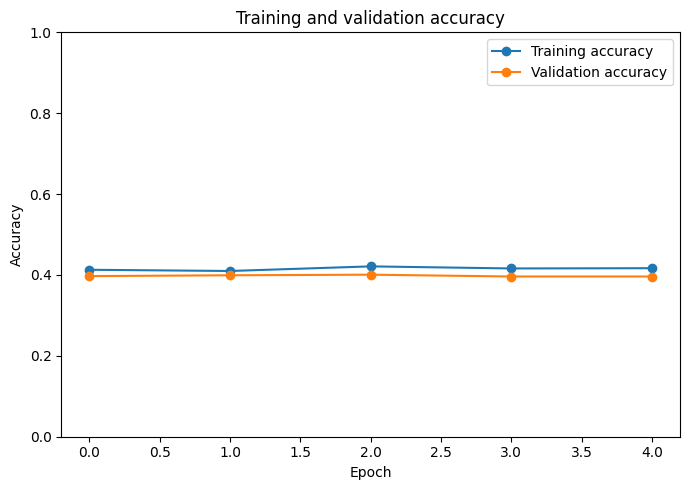

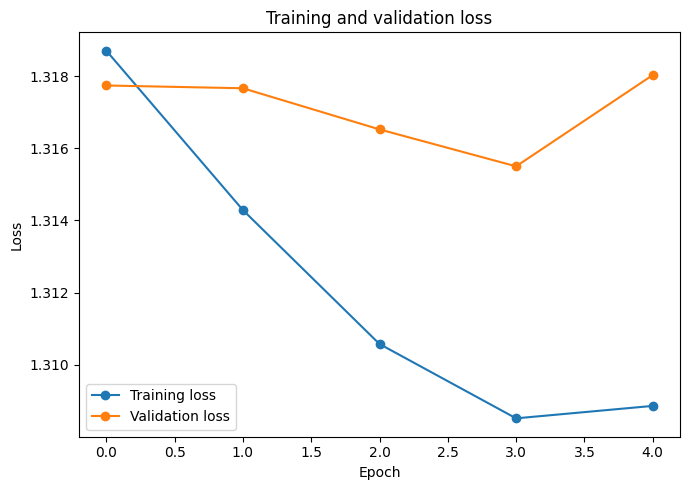

In [35]:
history = model.fit(
    [X_seq_train, X_motif_train],  # or X_train for CNN-only
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig("training_validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], marker="o", label="Training loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.tight_layout()
plt.savefig("training_validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()

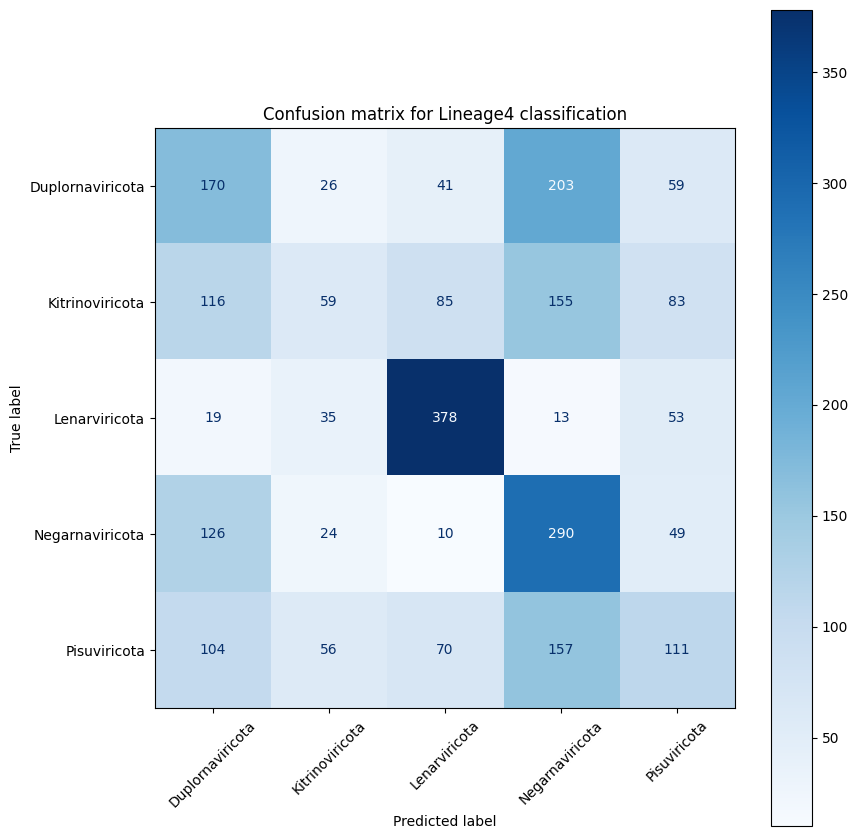

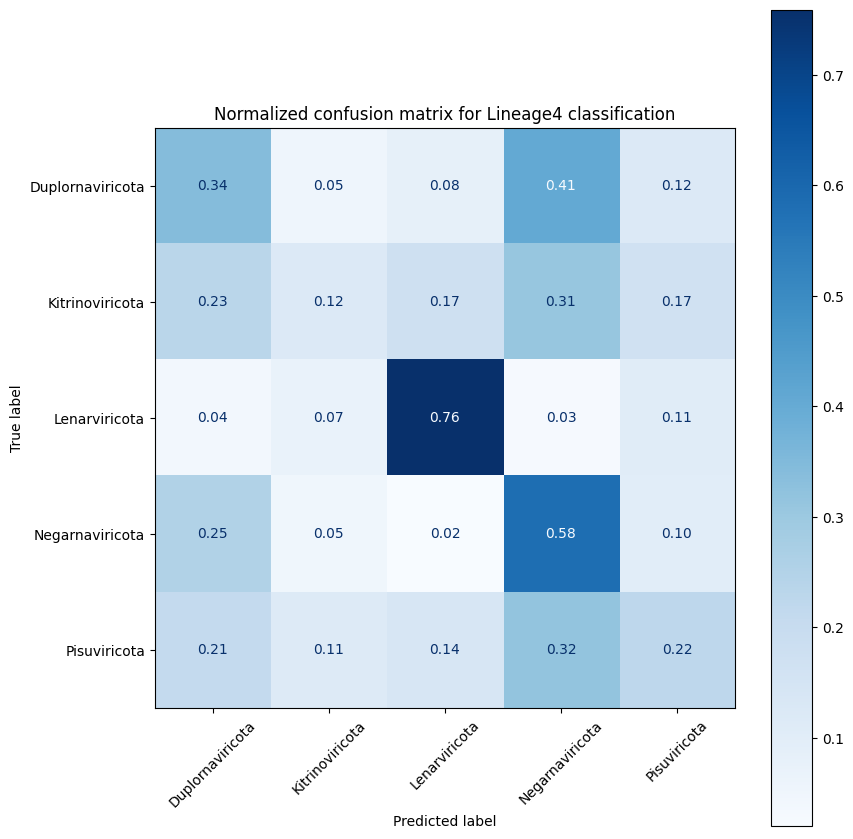

In [36]:
cm = confusion_matrix(
    test_df["true_lineage"],
    test_df["predicted_lineage"],
    labels=le.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)

plt.title("Confusion matrix for Lineage4 classification")
plt.tight_layout()
plt.savefig("confusion_matrix_lineage4.png", dpi=300, bbox_inches="tight")
plt.show()

cm_norm = confusion_matrix(
    test_df["true_lineage"],
    test_df["predicted_lineage"],
    labels=le.classes_,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45, values_format=".2f")

plt.title("Normalized confusion matrix for Lineage4 classification")
plt.tight_layout()
plt.savefig("confusion_matrix_lineage4_normalized.png", dpi=300, bbox_inches="tight")
plt.show()


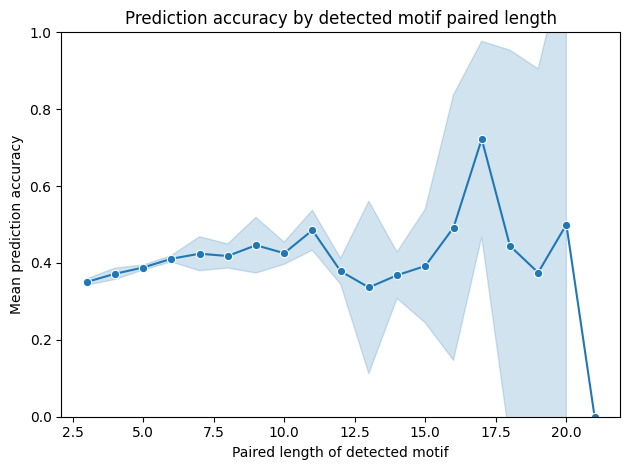

In [37]:
paired_accuracy_df = (
    motif_context_df
    .groupby(["seed", "paired_length"])
    .agg(
        n_occurrences=("motif_id", "size"),
        accuracy=("correct", "mean"),
        mean_confidence=("prediction_confidence", "mean")
    )
    .reset_index()
)

sns.lineplot(
    data=paired_accuracy_df.sort_values("paired_length"),
    x="paired_length",
    y="accuracy",
    marker="o",
    errorbar="sd"
)

plt.ylim(0, 1)
plt.xlabel("Paired length of detected motif")
plt.ylabel("Mean prediction accuracy")
plt.title("Prediction accuracy by detected motif paired length")

plt.tight_layout()
plt.savefig("real_accuracy_by_detected_motif_paired_length.png", dpi=300, bbox_inches="tight")
plt.show()

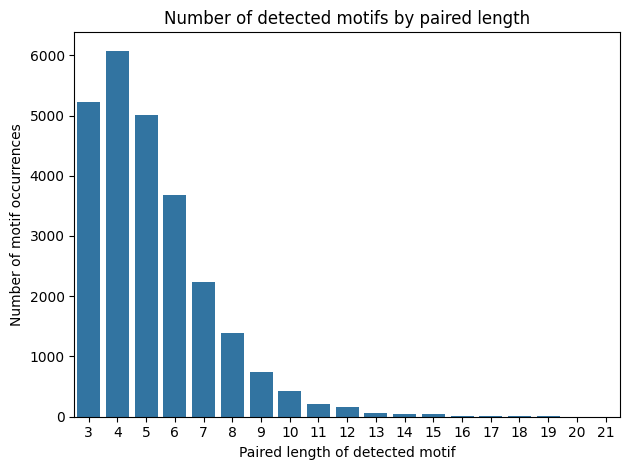

In [38]:
count_df = (
    motif_context_df
    .groupby("paired_length")
    .size()
    .reset_index(name="n_occurrences")
)

sns.barplot(
    data=count_df,
    x="paired_length",
    y="n_occurrences"
)

plt.xlabel("Paired length of detected motif")
plt.ylabel("Number of motif occurrences")
plt.title("Number of detected motifs by paired length")

plt.tight_layout()
plt.savefig("detected_motif_count_by_paired_length.png", dpi=300, bbox_inches="tight")
plt.show()

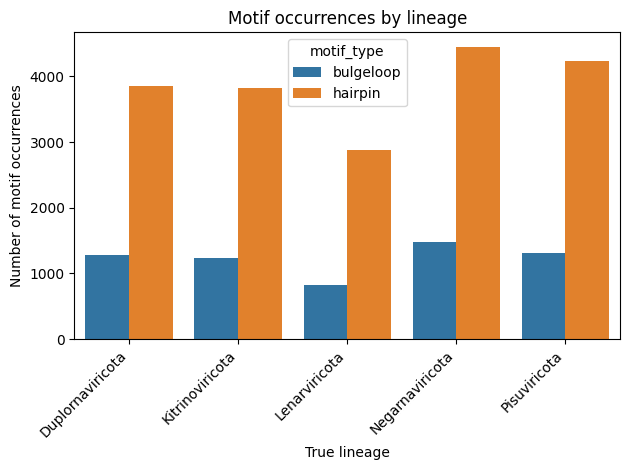

In [39]:
motif_count_lineage = (
    motif_context_df
    .groupby(["true_lineage", "motif_type"])
    .size()
    .reset_index(name="n_occurrences")
)

sns.barplot(
    data=motif_count_lineage,
    x="true_lineage",
    y="n_occurrences",
    hue="motif_type"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("True lineage")
plt.ylabel("Number of motif occurrences")
plt.title("Motif occurrences by lineage")

plt.tight_layout()
plt.savefig("motif_occurrences_by_lineage.png", dpi=300, bbox_inches="tight")
plt.show()

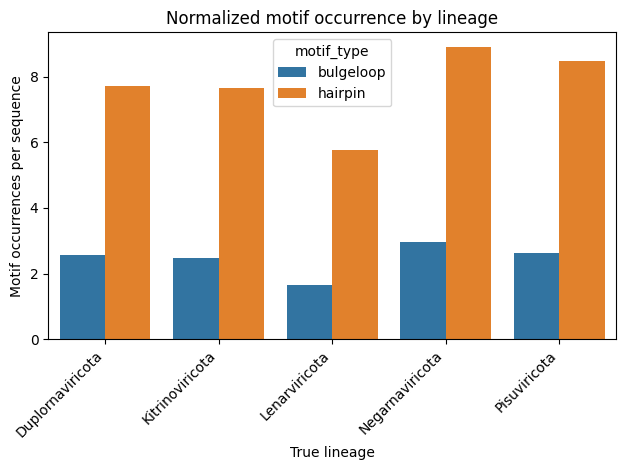

In [40]:
lineage_sizes = (
    test_df
    .groupby("true_lineage")
    .size()
    .reset_index(name="n_sequences")
)

motif_count_lineage_norm = motif_count_lineage.merge(
    lineage_sizes,
    on="true_lineage",
    how="left"
)

motif_count_lineage_norm["occurrences_per_sequence"] = (
    motif_count_lineage_norm["n_occurrences"] /
    motif_count_lineage_norm["n_sequences"]
)

sns.barplot(
    data=motif_count_lineage_norm,
    x="true_lineage",
    y="occurrences_per_sequence",
    hue="motif_type"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("True lineage")
plt.ylabel("Motif occurrences per sequence")
plt.title("Normalized motif occurrence by lineage")

plt.tight_layout()
plt.savefig("motif_occurrences_per_sequence_by_lineage.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
filter_idx = 0
sample_idx = 0

# Print layer names so you know which layer to inspect
for layer in model.layers:
    print(layer.name)

# Use the actual first Conv1D layer name from your model
conv_layer_name = "conv1d_4"

activation_model = Model(
    inputs=model.input,
    outputs=model.get_layer(conv_layer_name).output
)

# Get activations for one test sequence
activations = activation_model.predict(
    [
        X_seq_test[sample_idx:sample_idx + 1],
        X_motif_test[sample_idx:sample_idx + 1]
    ],
    verbose=0
)

print("Activation shape:", activations.shape)

sequence_input
conv1d_4
max_pooling1d_2
conv1d_5
motif_context_input
global_max_pooling1d_2
dense_6
concatenate_2
dense_7
dropout_2
dense_8
Activation shape: (1, 993, 32)


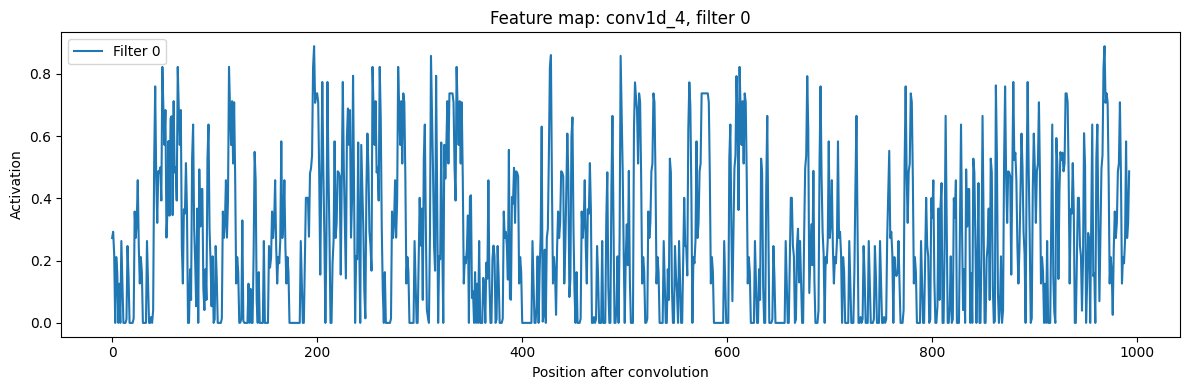

In [42]:
plt.figure(figsize=(12, 4))

plt.plot(
    activations[0, :, filter_idx],
    label=f"Filter {filter_idx}"
)

plt.xlabel("Position after convolution")
plt.ylabel("Activation")
plt.title(f"Feature map: {conv_layer_name}, filter {filter_idx}")

plt.legend()
plt.tight_layout()
plt.savefig("feature_map_filter0_no_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
row_index = test_df.index[sample_idx]

motifs_for_seq = motif_context_df[
    (motif_context_df["row_index"] == row_index) &
    (motif_context_df["seed"] == seed)
].sort_values("motif_start")

print(motifs_for_seq[[
    "motif_type",
    "motif_start",
    "motif_end",
    "paired_length"
]].head())

      motif_type  motif_start  motif_end  paired_length
16782    hairpin            0         27              4
16783    hairpin          393        424              6
16784    hairpin          456        483              5
16785  bulgeloop          700        731              4
16786    hairpin          709        731              4


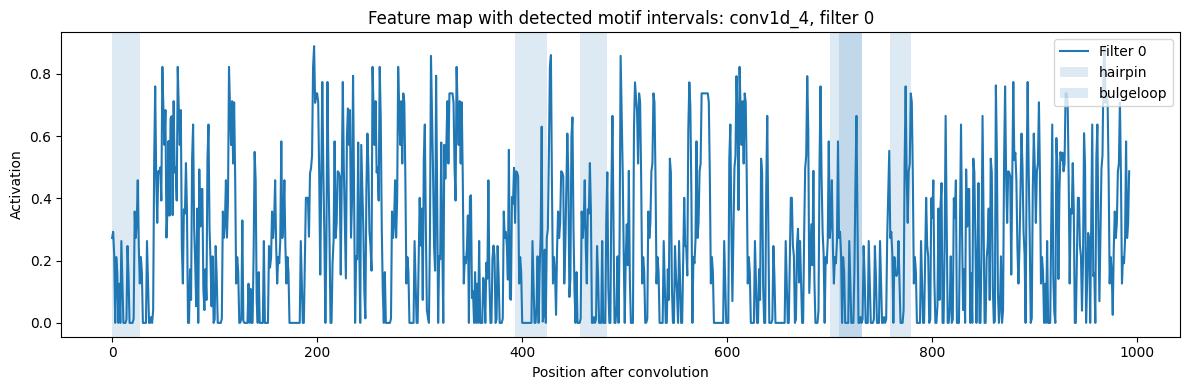

In [44]:
plt.figure(figsize=(12, 4))

plt.plot(
    activations[0, :, filter_idx],
    label=f"Filter {filter_idx}"
)

for _, r in motifs_for_seq.iterrows():
    plt.axvspan(
        r["motif_start"],
        r["motif_end"],
        alpha=0.15,
        label=r["motif_type"]
    )

plt.xlabel("Position after convolution")
plt.ylabel("Activation")
plt.title(f"Feature map with detected motif intervals: {conv_layer_name}, filter {filter_idx}")

# Avoid repeated labels in legend
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), loc="upper right")

plt.tight_layout()
plt.savefig("feature_map_with_detected_motif_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

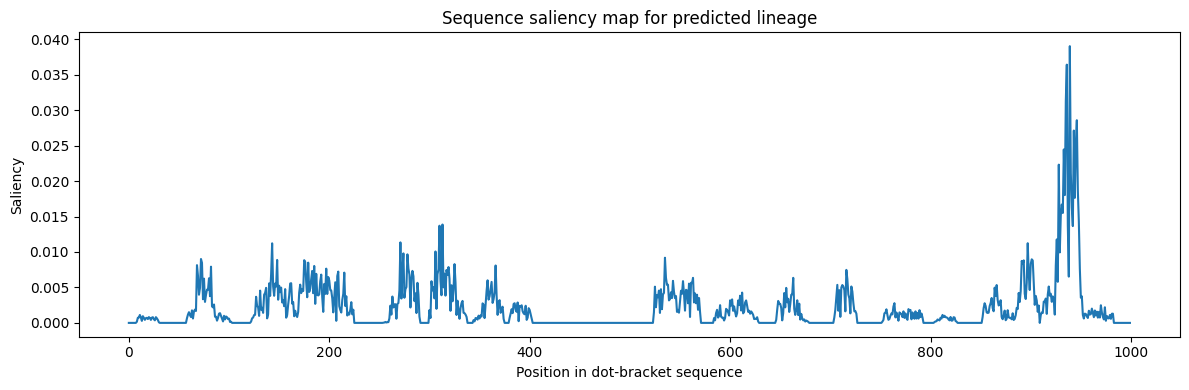

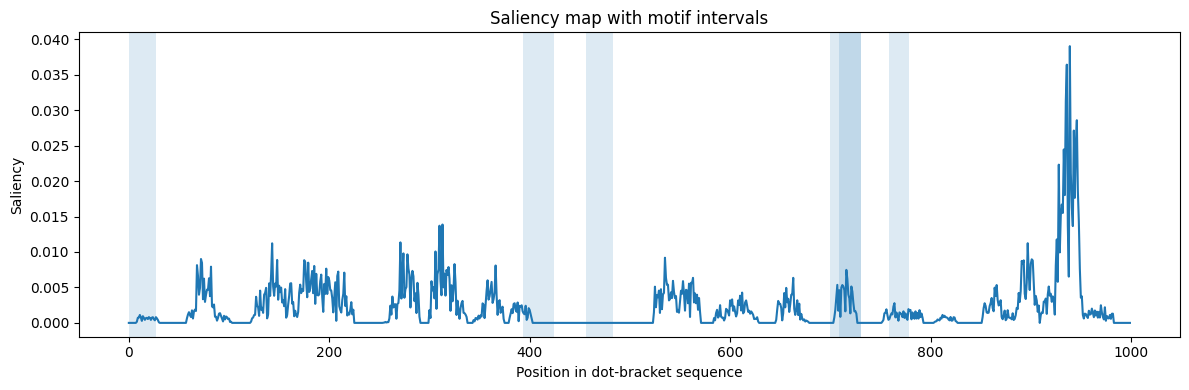

In [45]:
sample_idx = 0

x_seq_sample = tensorflow.convert_to_tensor(
    X_seq_test[sample_idx:sample_idx + 1],
    dtype=tensorflow.float32
)

x_motif_sample = tensorflow.convert_to_tensor(
    X_motif_test[sample_idx:sample_idx + 1],
    dtype=tensorflow.float32
)

with tensorflow.GradientTape() as tape:
    tape.watch(x_seq_sample)
    pred = model([x_seq_sample, x_motif_sample])
    class_idx = tensorflow.argmax(pred[0])
    class_score = pred[:, class_idx]

grads = tape.gradient(class_score, x_seq_sample)
saliency = tensorflow.reduce_max(tensorflow.abs(grads), axis=-1).numpy()[0]

plt.figure(figsize=(12, 4))
plt.plot(saliency)

plt.xlabel("Position in dot-bracket sequence")
plt.ylabel("Saliency")
plt.title("Sequence saliency map for predicted lineage")

plt.tight_layout()
plt.savefig("multi_input_saliency_map.png", dpi=300, bbox_inches="tight")
plt.show()

row_index = test_df.index[sample_idx]

motifs_for_seq = motif_context_df[
    (motif_context_df["row_index"] == row_index) &
    (motif_context_df["seed"] == seed)
]

plt.figure(figsize=(12, 4))
plt.plot(saliency, label="Saliency")

for _, r in motifs_for_seq.iterrows():
    plt.axvspan(r["motif_start"], r["motif_end"], alpha=0.15)

plt.xlabel("Position in dot-bracket sequence")
plt.ylabel("Saliency")
plt.title("Saliency map with motif intervals")

plt.tight_layout()
plt.savefig("saliency_with_motif_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

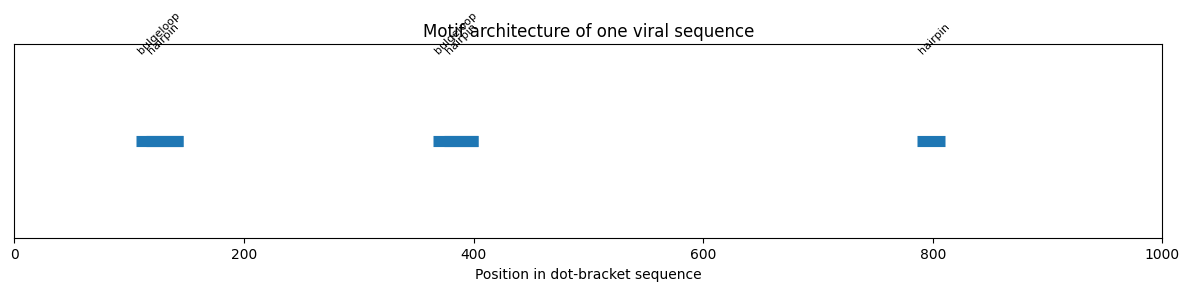

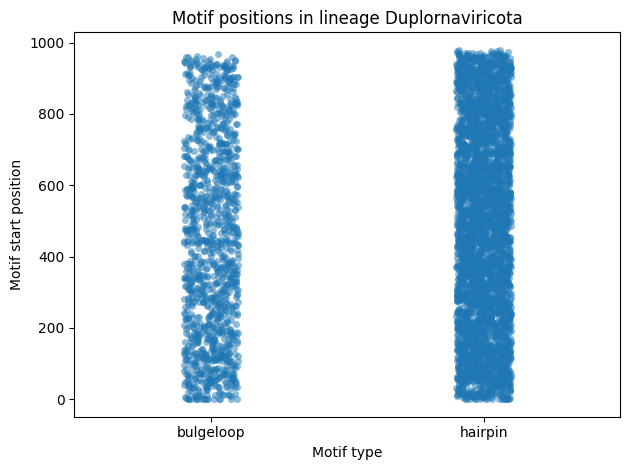

In [46]:
sequence_id = motif_context_df["row_index"].iloc[0]

seq_motifs = motif_context_df[
    motif_context_df["row_index"] == sequence_id
].sort_values("motif_start")

plt.figure(figsize=(12, 3))

for _, r in seq_motifs.iterrows():
    plt.hlines(
        y=1,
        xmin=r["motif_start"],
        xmax=r["motif_end"],
        linewidth=8
    )
    plt.text(
        r["motif_start"],
        1.05,
        r["motif_type"],
        rotation=45,
        fontsize=8
    )

plt.xlim(0, 1000)
plt.yticks([])
plt.xlabel("Position in dot-bracket sequence")
plt.title("Motif architecture of one viral sequence")

plt.tight_layout()
plt.savefig("motif_timeline_one_sequence.png", dpi=300, bbox_inches="tight")
plt.show()

lineage = motif_context_df["true_lineage"].iloc[0]

plot_df = motif_context_df[
    motif_context_df["true_lineage"] == lineage
]

sns.stripplot(
    data=plot_df,
    x="motif_type",
    y="motif_start",
    jitter=True,
    alpha=0.5
)

plt.xlabel("Motif type")
plt.ylabel("Motif start position")
plt.title(f"Motif positions in lineage {lineage}")

plt.tight_layout()
plt.savefig("motif_positions_by_lineage.png", dpi=300, bbox_inches="tight")
plt.show()

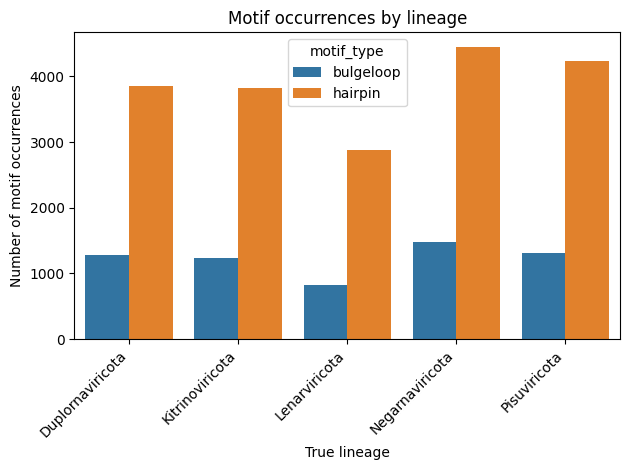

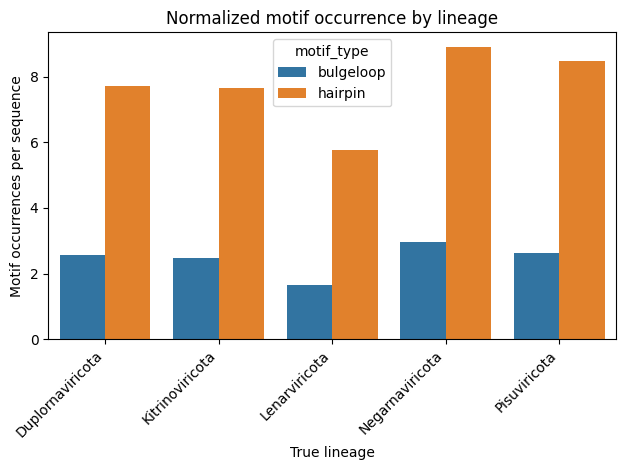

In [47]:
motif_count_lineage = (
    motif_context_df
    .groupby(["true_lineage", "motif_type"])
    .size()
    .reset_index(name="n_occurrences")
)

sns.barplot(
    data=motif_count_lineage,
    x="true_lineage",
    y="n_occurrences",
    hue="motif_type"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("True lineage")
plt.ylabel("Number of motif occurrences")
plt.title("Motif occurrences by lineage")

plt.tight_layout()
plt.savefig("motif_occurrences_by_lineage.png", dpi=300, bbox_inches="tight")
plt.show()

lineage_sizes = (
    test_df
    .groupby("true_lineage")
    .size()
    .reset_index(name="n_sequences")
)

motif_count_lineage_norm = motif_count_lineage.merge(
    lineage_sizes,
    on="true_lineage",
    how="left"
)

motif_count_lineage_norm["occurrences_per_sequence"] = (
    motif_count_lineage_norm["n_occurrences"] /
    motif_count_lineage_norm["n_sequences"]
)

sns.barplot(
    data=motif_count_lineage_norm,
    x="true_lineage",
    y="occurrences_per_sequence",
    hue="motif_type"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("True lineage")
plt.ylabel("Motif occurrences per sequence")
plt.title("Normalized motif occurrence by lineage")

plt.tight_layout()
plt.savefig("motif_occurrences_per_sequence_by_lineage.png", dpi=300, bbox_inches="tight")
plt.show()

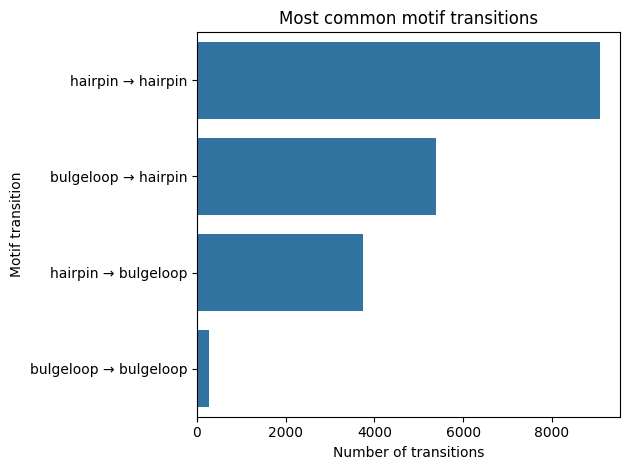

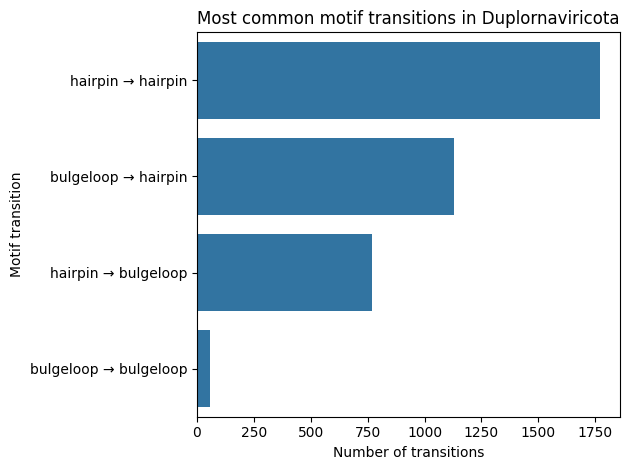

In [48]:
motif_context_df = motif_context_df.sort_values(
    ["seed", "row_index", "motif_start"]
)

motif_context_df["next_motif_type"] = (
    motif_context_df
    .groupby(["seed", "row_index"])["motif_type"]
    .shift(-1)
)

motif_transitions = (
    motif_context_df
    .dropna(subset=["next_motif_type"])
    .groupby(["true_lineage", "motif_type", "next_motif_type"])
    .size()
    .reset_index(name="n_transitions")
)

motif_transitions["transition"] = (
    motif_transitions["motif_type"]
    + " → "
    + motif_transitions["next_motif_type"]
)

top_transitions = (
    motif_transitions
    .groupby("transition")["n_transitions"]
    .sum()
    .reset_index()
    .sort_values("n_transitions", ascending=False)
    .head(10)
)

sns.barplot(
    data=top_transitions,
    x="n_transitions",
    y="transition"
)

plt.xlabel("Number of transitions")
plt.ylabel("Motif transition")
plt.title("Most common motif transitions")

plt.tight_layout()
plt.savefig("top_motif_transitions.png", dpi=300, bbox_inches="tight")
plt.show()

lineage = motif_transitions["true_lineage"].iloc[0]

plot_df = motif_transitions[
    motif_transitions["true_lineage"] == lineage
].copy()

plot_df["transition"] = (
    plot_df["motif_type"]
    + " → "
    + plot_df["next_motif_type"]
)

plot_df = plot_df.sort_values("n_transitions", ascending=False).head(10)

sns.barplot(
    data=plot_df,
    x="n_transitions",
    y="transition"
)

plt.xlabel("Number of transitions")
plt.ylabel("Motif transition")
plt.title(f"Most common motif transitions in {lineage}")

plt.tight_layout()
plt.savefig("top_motif_transitions_one_lineage.png", dpi=300, bbox_inches="tight")
plt.show()

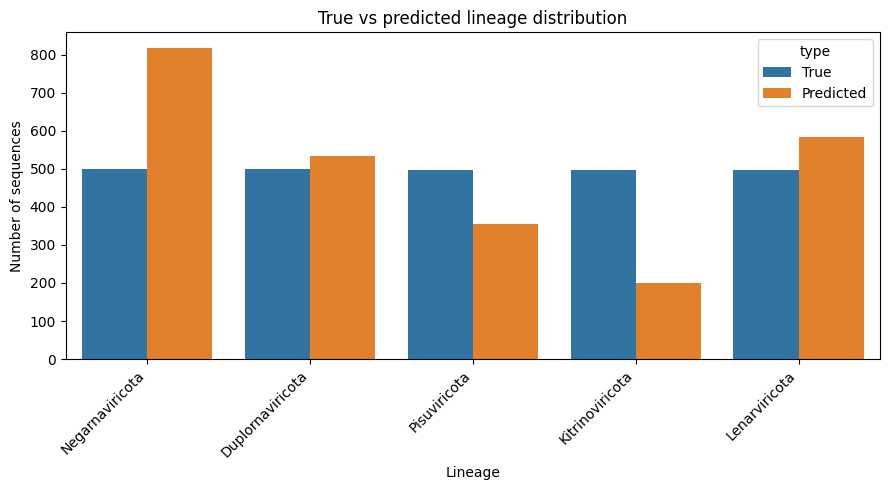

In [49]:

true_counts = (
    test_df["true_lineage"]
    .value_counts()
    .rename_axis("lineage")
    .reset_index(name="count")
)
true_counts["type"] = "True"

pred_counts = (
    test_df["predicted_lineage"]
    .value_counts()
    .rename_axis("lineage")
    .reset_index(name="count")
)
pred_counts["type"] = "Predicted"

distribution_df = pd.concat([true_counts, pred_counts], ignore_index=True)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=distribution_df,
    x="lineage",
    y="count",
    hue="type"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Lineage")
plt.ylabel("Number of sequences")
plt.title("True vs predicted lineage distribution")

plt.tight_layout()
plt.savefig("true_vs_predicted_lineage_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
report = classification_report(
    test_df["true_lineage"],
    test_df["predicted_lineage"],
    output_dict=True,
    zero_division=0
)

per_class_report = (
    pd.DataFrame(report)
    .T
    .reset_index()
    .rename(columns={"index": "lineage"})
)

per_class_report = per_class_report[
    per_class_report["lineage"].isin(le.classes_)
]

print(per_class_report)

            lineage  precision    recall  f1-score  support
0  Duplornaviricota   0.317757  0.340681  0.328820    499.0
1   Kitrinoviricota   0.295000  0.118474  0.169054    498.0
2     Lenarviricota   0.647260  0.759036  0.698706    498.0
3   Negarnaviricota   0.354523  0.581162  0.440395    499.0
4      Pisuviricota   0.312676  0.222892  0.260258    498.0


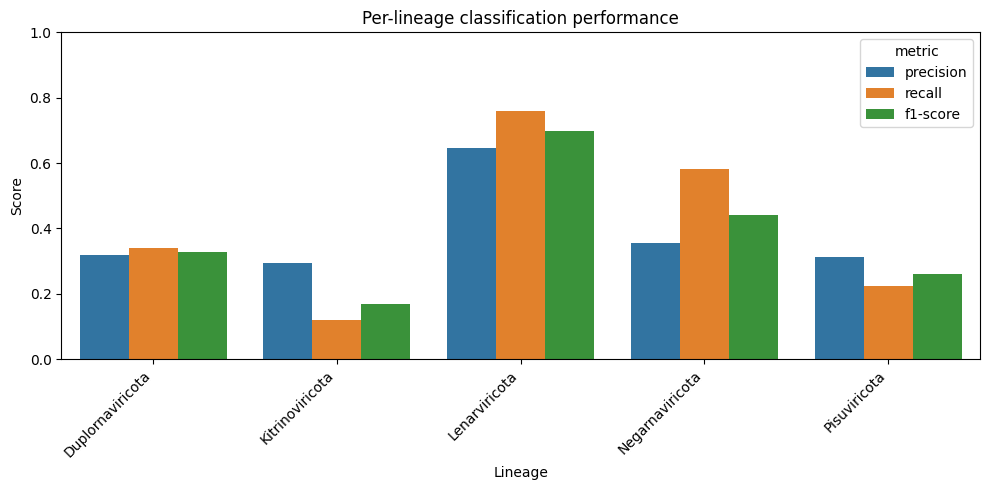

In [51]:
metrics_long = per_class_report.melt(
    id_vars="lineage",
    value_vars=["precision", "recall", "f1-score"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=metrics_long,
    x="lineage",
    y="score",
    hue="metric"
)

plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Lineage")
plt.ylabel("Score")
plt.title("Per-lineage classification performance")

plt.tight_layout()
plt.savefig("per_lineage_precision_recall_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [52]:
bias_df = true_counts.merge(
    pred_counts,
    on="lineage",
    suffixes=("_true", "_predicted")
)

bias_df["prediction_bias_ratio"] = (
    bias_df["count_predicted"] / bias_df["count_true"]
)

print(bias_df)

            lineage  count_true type_true  count_predicted type_predicted  \
0   Negarnaviricota         499      True              818      Predicted   
1  Duplornaviricota         499      True              535      Predicted   
2      Pisuviricota         498      True              355      Predicted   
3   Kitrinoviricota         498      True              200      Predicted   
4     Lenarviricota         498      True              584      Predicted   

   prediction_bias_ratio  
0               1.639279  
1               1.072144  
2               0.712851  
3               0.401606  
4               1.172691  


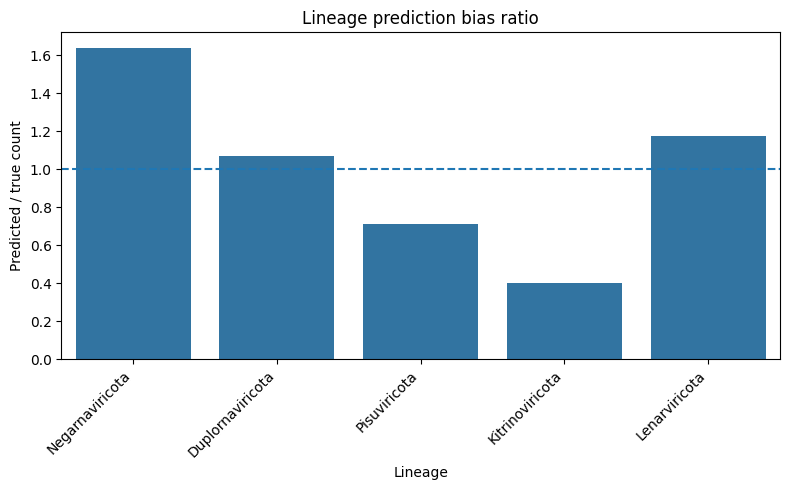

In [53]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=bias_df,
    x="lineage",
    y="prediction_bias_ratio"
)

plt.axhline(1, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Lineage")
plt.ylabel("Predicted / true count")
plt.title("Lineage prediction bias ratio")

plt.tight_layout()
plt.savefig("lineage_prediction_bias_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

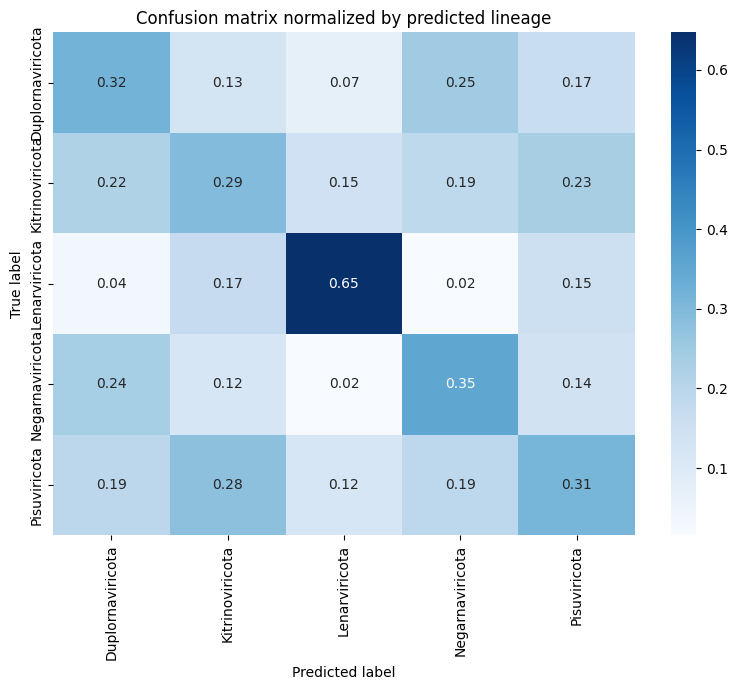

In [54]:

labels = list(le.classes_)

cm = confusion_matrix(
    test_df["true_lineage"],
    test_df["predicted_lineage"],
    labels=labels
)

cm_pred_norm = cm / cm.sum(axis=0, keepdims=True)
cm_pred_norm = np.nan_to_num(cm_pred_norm)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_pred_norm,
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix normalized by predicted lineage")

plt.tight_layout()
plt.savefig("confusion_matrix_normalized_by_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

In [55]:
errors_df = test_df[
    test_df["true_lineage"] != test_df["predicted_lineage"]
].copy()

error_pairs = (
    errors_df
    .groupby(["true_lineage", "predicted_lineage"])
    .size()
    .reset_index(name="n_errors")
    .sort_values("n_errors", ascending=False)
)

print(error_pairs.head(20))

        true_lineage predicted_lineage  n_errors
2   Duplornaviricota   Negarnaviricota       203
19      Pisuviricota   Negarnaviricota       157
6    Kitrinoviricota   Negarnaviricota       155
12   Negarnaviricota  Duplornaviricota       126
4    Kitrinoviricota  Duplornaviricota       116
16      Pisuviricota  Duplornaviricota       104
5    Kitrinoviricota     Lenarviricota        85
7    Kitrinoviricota      Pisuviricota        83
18      Pisuviricota     Lenarviricota        70
3   Duplornaviricota      Pisuviricota        59
17      Pisuviricota   Kitrinoviricota        56
11     Lenarviricota      Pisuviricota        53
15   Negarnaviricota      Pisuviricota        49
1   Duplornaviricota     Lenarviricota        41
9      Lenarviricota   Kitrinoviricota        35
0   Duplornaviricota   Kitrinoviricota        26
13   Negarnaviricota   Kitrinoviricota        24
8      Lenarviricota  Duplornaviricota        19
10     Lenarviricota   Negarnaviricota        13
14   Negarnaviricota

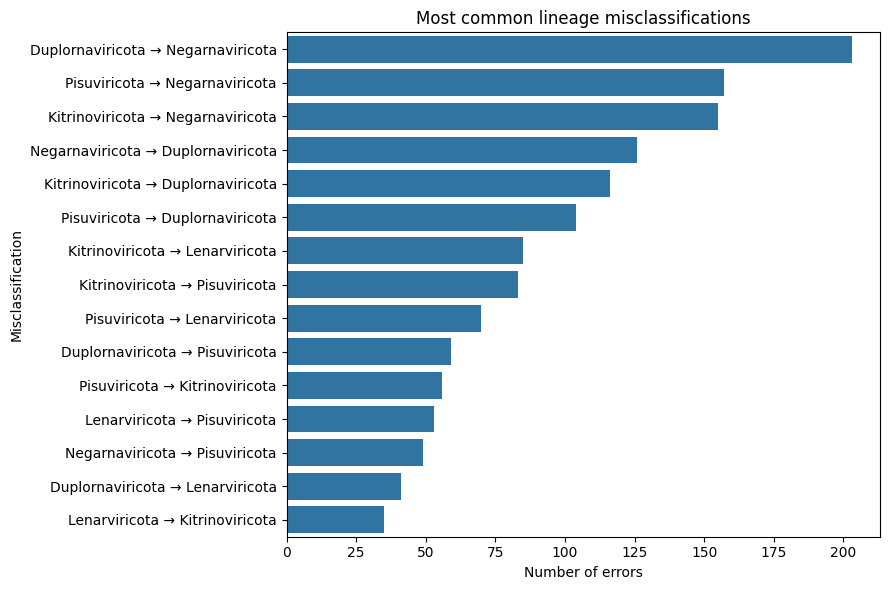

In [56]:
error_pairs["error_pair"] = (
    error_pairs["true_lineage"] + " → " + error_pairs["predicted_lineage"]
)

top_errors = error_pairs.head(15)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=top_errors,
    y="error_pair",
    x="n_errors"
)

plt.xlabel("Number of errors")
plt.ylabel("Misclassification")
plt.title("Most common lineage misclassifications")

plt.tight_layout()
plt.savefig("most_common_lineage_misclassifications.png", dpi=300, bbox_inches="tight")
plt.show()

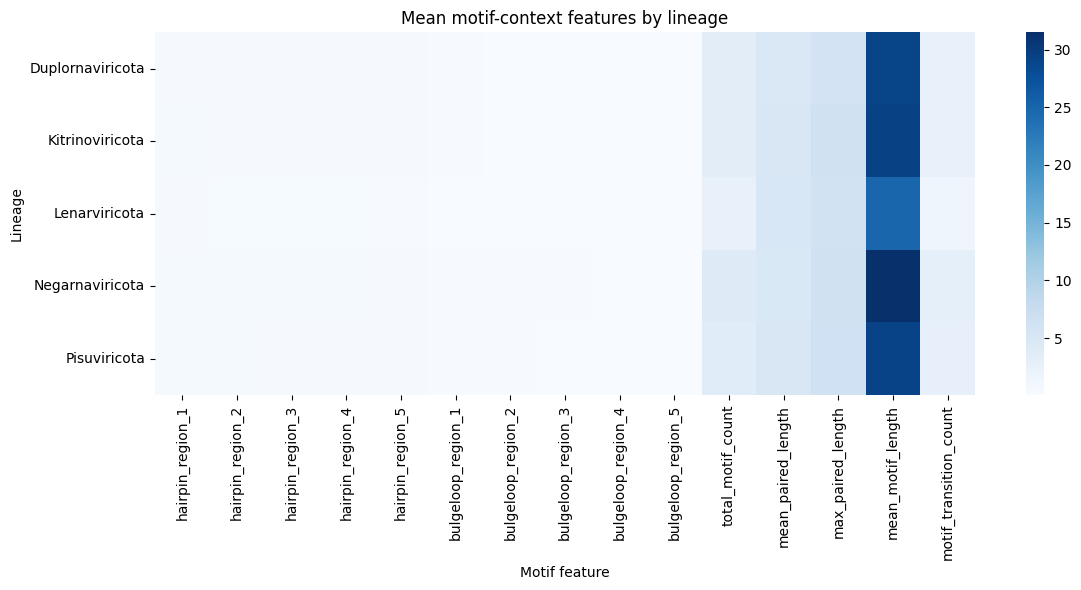

In [57]:
motif_lineage_df = pd.concat(
    [
        balanced_df[["Lineage4"]].reset_index(drop=True),
        motif_feature_df_clean.reset_index(drop=True)
    ],
    axis=1
)

motif_means_by_lineage = (
    motif_lineage_df
    .groupby("Lineage4")
    .mean()
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    motif_means_by_lineage,
    cmap="Blues",
    annot=False
)

plt.xlabel("Motif feature")
plt.ylabel("Lineage")
plt.title("Mean motif-context features by lineage")

plt.tight_layout()
plt.savefig("motif_feature_means_by_lineage_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
def evaluate_classification_plots(test_df, le, model_name):
    labels = list(le.classes_)

    # Classification report
    report = classification_report(
        test_df["true_lineage"],
        test_df["predicted_lineage"],
        output_dict=True,
        zero_division=0
    )

    per_class_report = (
        pd.DataFrame(report)
        .T
        .reset_index()
        .rename(columns={"index": "lineage"})
    )

    per_class_report = per_class_report[
        per_class_report["lineage"].isin(labels)
    ]

    metrics_long = per_class_report.melt(
        id_vars="lineage",
        value_vars=["precision", "recall", "f1-score"],
        var_name="metric",
        value_name="score"
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=metrics_long,
        x="lineage",
        y="score",
        hue="metric"
    )
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Lineage")
    plt.ylabel("Score")
    plt.title(f"Per-lineage classification performance: {model_name}")
    plt.tight_layout()
    plt.savefig(f"{model_name}_per_lineage_precision_recall_f1.png", dpi=300, bbox_inches="tight")
    plt.show()

    # True vs predicted distribution
    true_counts = (
        test_df["true_lineage"]
        .value_counts()
        .rename_axis("lineage")
        .reset_index(name="count")
    )
    true_counts["type"] = "True"

    pred_counts = (
        test_df["predicted_lineage"]
        .value_counts()
        .rename_axis("lineage")
        .reset_index(name="count")
    )
    pred_counts["type"] = "Predicted"

    distribution_df = pd.concat([true_counts, pred_counts], ignore_index=True)

    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=distribution_df,
        x="lineage",
        y="count",
        hue="type"
    )
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Lineage")
    plt.ylabel("Number of sequences")
    plt.title(f"True vs predicted lineage distribution: {model_name}")
    plt.tight_layout()
    plt.savefig(f"{model_name}_true_vs_predicted_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Prediction bias ratio
    bias_df = true_counts.merge(
        pred_counts,
        on="lineage",
        suffixes=("_true", "_predicted")
    )

    bias_df["prediction_bias_ratio"] = (
        bias_df["count_predicted"] / bias_df["count_true"]
    )

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=bias_df,
        x="lineage",
        y="prediction_bias_ratio"
    )
    plt.axhline(1, linestyle="--")
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Lineage")
    plt.ylabel("Predicted / true count")
    plt.title(f"Prediction bias ratio: {model_name}")
    plt.tight_layout()
    plt.savefig(f"{model_name}_prediction_bias_ratio.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Normalized confusion matrix by true label
    cm_true = confusion_matrix(
        test_df["true_lineage"],
        test_df["predicted_lineage"],
        labels=labels,
        normalize="true"
    )

    plt.figure(figsize=(8, 7))
    sns.heatmap(
        cm_true,
        annot=True,
        fmt=".2f",
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues"
    )
    plt.xlabel("Predicted lineage")
    plt.ylabel("True lineage")
    plt.title(f"Confusion matrix normalized by true lineage: {model_name}")
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix_true_normalized.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Normalized confusion matrix by predicted label
    cm = confusion_matrix(
        test_df["true_lineage"],
        test_df["predicted_lineage"],
        labels=labels
    )

    cm_pred = cm / cm.sum(axis=0, keepdims=True)
    cm_pred = np.nan_to_num(cm_pred)

    plt.figure(figsize=(8, 7))
    sns.heatmap(
        cm_pred,
        annot=True,
        fmt=".2f",
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues"
    )
    plt.xlabel("Predicted lineage")
    plt.ylabel("True lineage")
    plt.title(f"Confusion matrix normalized by predicted lineage: {model_name}")
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix_predicted_normalized.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Most common misclassifications
    errors_df = test_df[
        test_df["true_lineage"] != test_df["predicted_lineage"]
    ].copy()

    error_pairs = (
        errors_df
        .groupby(["true_lineage", "predicted_lineage"])
        .size()
        .reset_index(name="n_errors")
        .sort_values("n_errors", ascending=False)
    )

    error_pairs["error_pair"] = (
        error_pairs["true_lineage"] + " → " + error_pairs["predicted_lineage"]
    )

    top_errors = error_pairs.head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=top_errors,
        y="error_pair",
        x="n_errors"
    )
    plt.xlabel("Number of errors")
    plt.ylabel("Misclassification")
    plt.title(f"Most common lineage misclassifications: {model_name}")
    plt.tight_layout()
    plt.savefig(f"{model_name}_most_common_misclassifications.png", dpi=300, bbox_inches="tight")
    plt.show()

    return per_class_report, bias_df, error_pairs

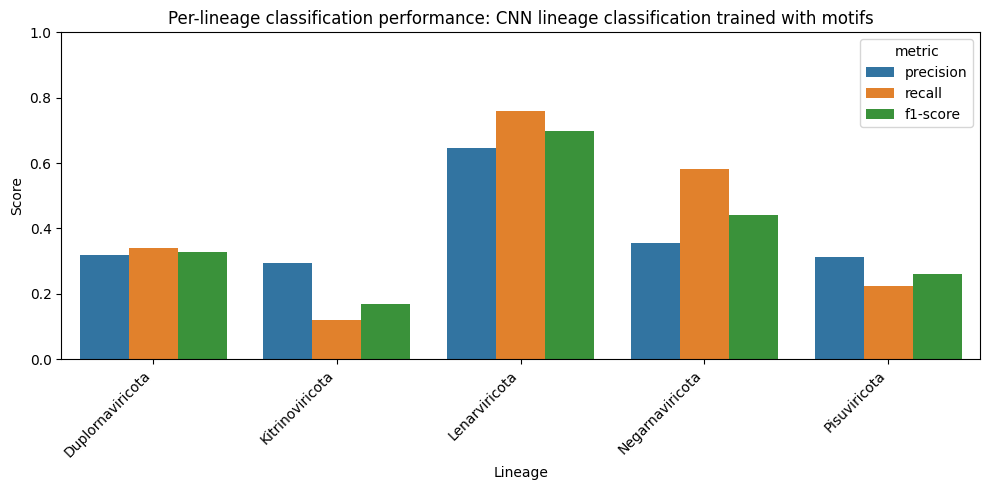

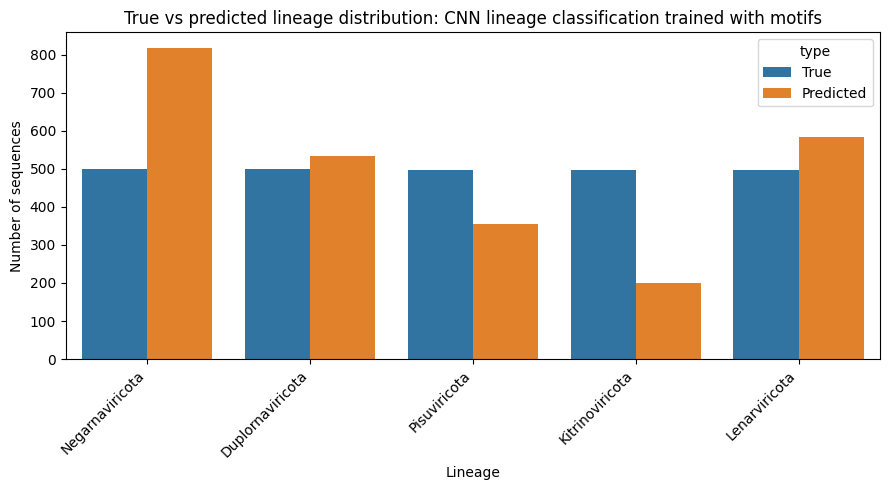

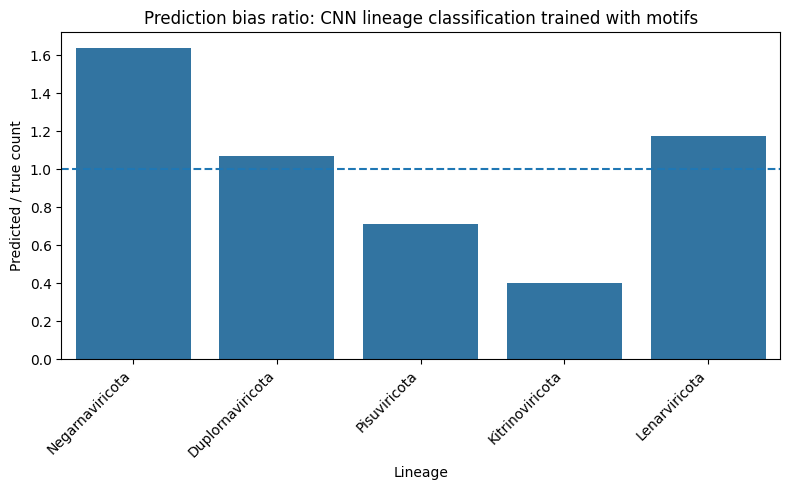

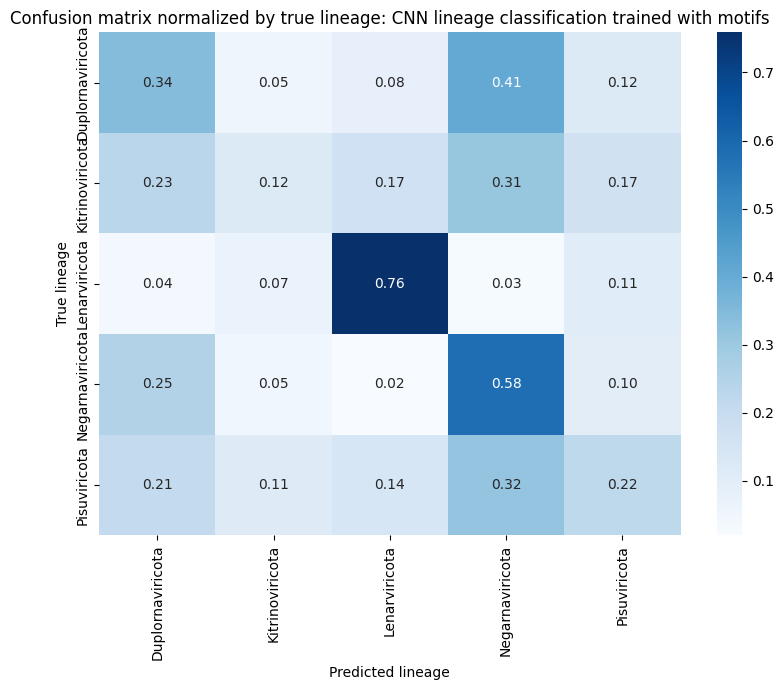

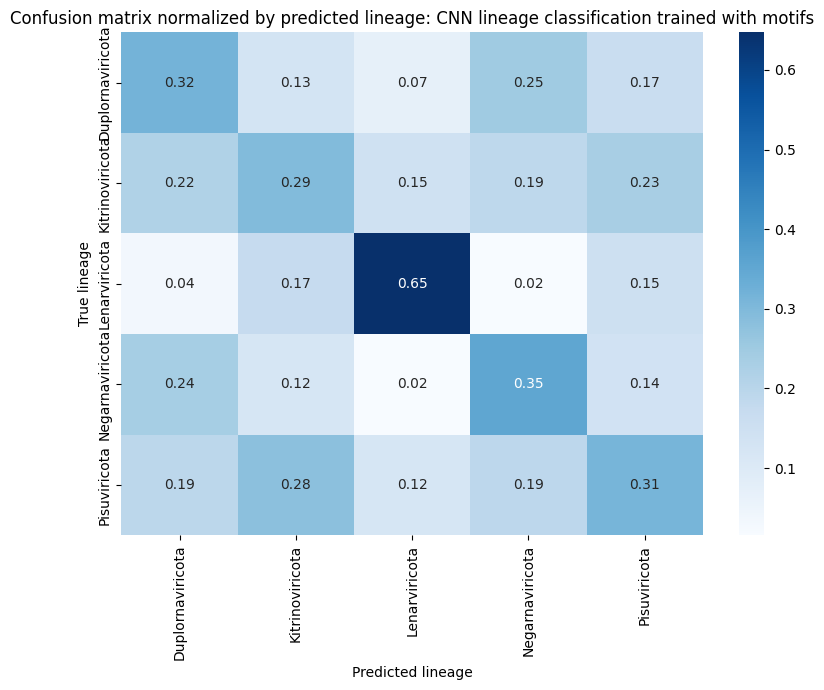

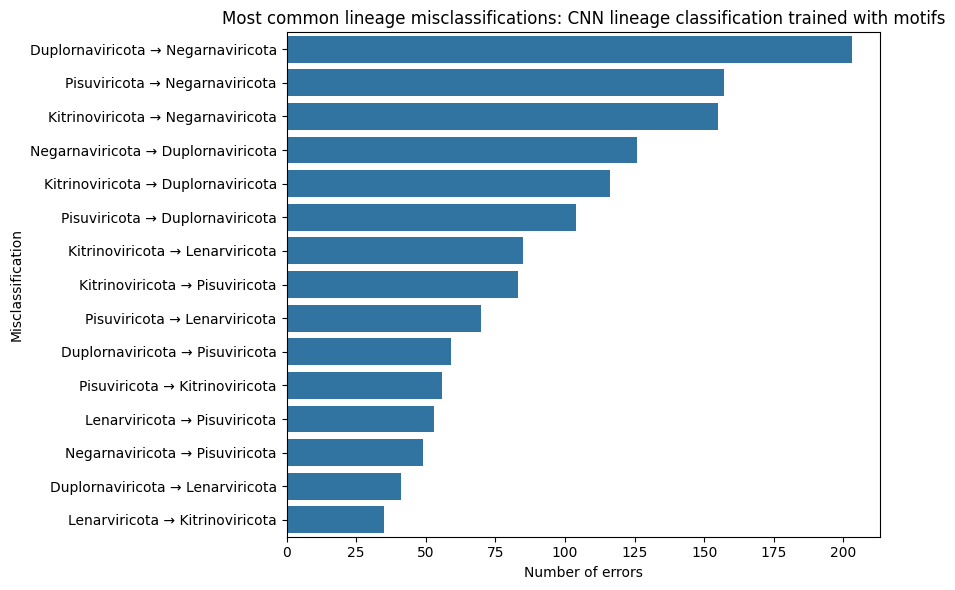

(            lineage  precision    recall  f1-score  support
 0  Duplornaviricota   0.317757  0.340681  0.328820    499.0
 1   Kitrinoviricota   0.295000  0.118474  0.169054    498.0
 2     Lenarviricota   0.647260  0.759036  0.698706    498.0
 3   Negarnaviricota   0.354523  0.581162  0.440395    499.0
 4      Pisuviricota   0.312676  0.222892  0.260258    498.0,
             lineage  count_true type_true  count_predicted type_predicted  \
 0   Negarnaviricota         499      True              818      Predicted   
 1  Duplornaviricota         499      True              535      Predicted   
 2      Pisuviricota         498      True              355      Predicted   
 3   Kitrinoviricota         498      True              200      Predicted   
 4     Lenarviricota         498      True              584      Predicted   
 
    prediction_bias_ratio  
 0               1.639279  
 1               1.072144  
 2               0.712851  
 3               0.401606  
 4               1.1726

In [59]:
evaluate_classification_plots(test_df, le, "CNN lineage classification trained with motifs")

In [ ]:

cnn_motif_results_df = pd.DataFrame(results)

cnn_motif_predictions_df = pd.concat(
    prediction_outputs,
    ignore_index=True
)

cnn_motif_results_df.to_csv(
    "cnn_plus_motif_lineage_metrics.csv",
    index=False
)

cnn_motif_predictions_df.to_csv(
    "cnn_plus_motif_predictions.csv",
    index=False
)

In [ ]:

motif_features_per_sequence = pd.DataFrame(
    list(cnn_motif_predictions_df["fold"].apply(motif_context_vector_regex))
)

cnn_motif_predictions_with_features_df = pd.concat(
    [
        cnn_motif_predictions_df.reset_index(drop=True),
        motif_features_per_sequence.reset_index(drop=True)
    ],
    axis=1
)

cnn_motif_predictions_with_features_df.to_csv(
    "cnn_plus_motif_predictions_with_motif_features.csv",
    index=False
)

In [62]:
cnn_motif_wrong_df = cnn_motif_predictions_with_features_df[
    cnn_motif_predictions_with_features_df["correct"] == 0
].copy()

cnn_motif_wrong_df["error_type"] = (
    cnn_motif_wrong_df["true_lineage"]
    + " → "
    + cnn_motif_wrong_df["predicted_lineage"]
)

cnn_motif_wrong_df.to_csv(
    "cnn_plus_motif_wrongly_classified_sequences.csv",
    index=False
)

In [63]:
cnn_motif_error_counts = (
    cnn_motif_wrong_df["error_type"]
    .value_counts()
    .reset_index()
)

cnn_motif_error_counts.columns = ["error_type", "n_errors"]

print(cnn_motif_error_counts.head(20))

cnn_motif_error_counts.to_csv(
    "cnn_plus_motif_common_error_types.csv",
    index=False
)

                            error_type  n_errors
0   Duplornaviricota → Negarnaviricota       607
1       Pisuviricota → Negarnaviricota       434
2    Kitrinoviricota → Negarnaviricota       400
3   Negarnaviricota → Duplornaviricota       353
4   Kitrinoviricota → Duplornaviricota       300
5       Kitrinoviricota → Pisuviricota       287
6      Pisuviricota → Duplornaviricota       275
7      Kitrinoviricota → Lenarviricota       252
8       Pisuviricota → Kitrinoviricota       222
9         Pisuviricota → Lenarviricota       217
10     Duplornaviricota → Pisuviricota       195
11      Negarnaviricota → Pisuviricota       161
12        Lenarviricota → Pisuviricota       149
13  Duplornaviricota → Kitrinoviricota       144
14   Negarnaviricota → Kitrinoviricota       119
15    Duplornaviricota → Lenarviricota       119
16     Lenarviricota → Kitrinoviricota       118
17    Lenarviricota → Duplornaviricota        48
18     Lenarviricota → Negarnaviricota        33
19     Negarnavirico

In [64]:
feature_cols = [
    col for col in cnn_motif_wrong_df.columns
    if (
        "region" in col
        or col in [
            "total_motif_count",
            "mean_paired_length",
            "max_paired_length",
            "mean_motif_length",
            "motif_transition_count",
            "prediction_confidence"
        ]
    )
]

X_wrong = cnn_motif_wrong_df[feature_cols].fillna(0).values

scaler = StandardScaler()
X_wrong_scaled = scaler.fit_transform(X_wrong)

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

cnn_motif_wrong_df["error_cluster"] = kmeans.fit_predict(X_wrong_scaled)

cnn_motif_wrong_df.to_csv(
    "cnn_plus_motif_wrong_sequences_clustered.csv",
    index=False
)

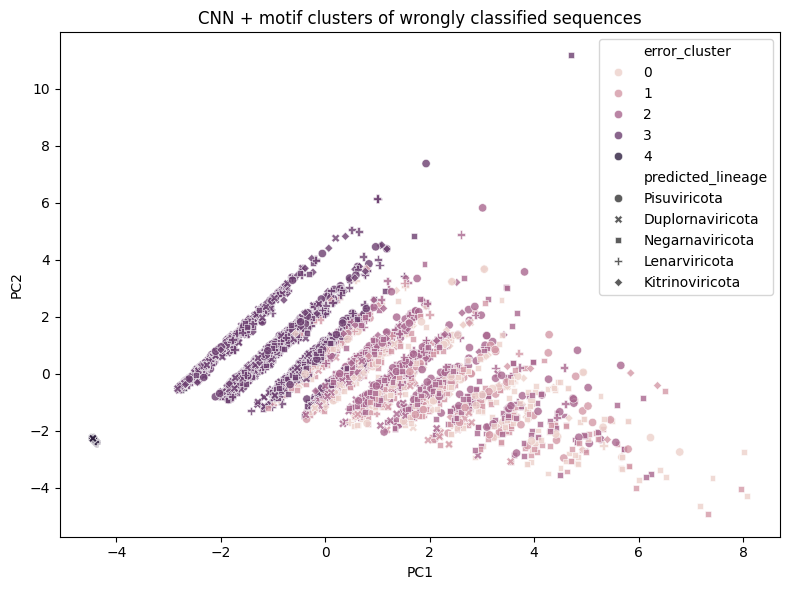

In [65]:
pca = PCA(n_components=2, random_state=42)
X_wrong_pca = pca.fit_transform(X_wrong_scaled)

cnn_motif_wrong_df["PC1"] = X_wrong_pca[:, 0]
cnn_motif_wrong_df["PC2"] = X_wrong_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=cnn_motif_wrong_df,
    x="PC1",
    y="PC2",
    hue="error_cluster",
    style="predicted_lineage",
    alpha=0.8
)

plt.title("CNN + motif clusters of wrongly classified sequences")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(
    "cnn_plus_motif_wrong_sequences_clusters.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [66]:
cluster_feature_summary = (
    cnn_motif_wrong_df
    .groupby("error_cluster")
    .agg(
        n_sequences=("correct", "size"),
        mean_total_motif_count=("total_motif_count", "mean"),
        mean_transition_count=("motif_transition_count", "mean"),
        mean_paired_length=("mean_paired_length", "mean"),
        mean_max_paired_length=("max_paired_length", "mean"),
        mean_motif_length=("mean_motif_length", "mean"),
        mean_confidence=("prediction_confidence", "mean")
    )
    .reset_index()
)

print(cluster_feature_summary)

   error_cluster  n_sequences  mean_total_motif_count  mean_transition_count  \
0              0          500                5.672000               4.672000   
1              1          532                5.392857               4.392857   
2              2         1119                5.099196               4.099196   
3              3         1997                2.060090               1.060090   
4              4          315                0.003175               0.000000   

   mean_paired_length  mean_max_paired_length  mean_motif_length  \
0            5.248555                7.578000          32.415315   
1            5.169461                7.287594          32.827243   
2            5.265216                7.628239          32.104232   
3            5.079619                5.836755          30.140127   
4            0.009524                0.009524           0.053968   

   mean_confidence  
0         0.331656  
1         0.334120  
2         0.338101  
3         0.328713  
4    

In [67]:
explained_variance = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_
})

print(explained_variance)

  component  explained_variance_ratio
0       PC1                  0.274546
1       PC2                  0.110953


In [68]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1_loading", "PC2_loading"]
)

print(
    pca_loadings
    .sort_values("PC1_loading", key=abs, ascending=False)
    .head(10)
)

print(
    pca_loadings
    .sort_values("PC2_loading", key=abs, ascending=False)
    .head(10)
)

pca_loadings.to_csv("pca_feature_loadings_wrong_sequences.csv")

                        PC1_loading  PC2_loading
total_motif_count          0.449748    -0.245480
motif_transition_count     0.436710    -0.297323
max_paired_length          0.336932     0.446359
mean_motif_length          0.284994     0.440239
mean_paired_length         0.262392     0.591272
hairpin_region_1           0.219969    -0.093466
hairpin_region_4           0.205186    -0.128577
hairpin_region_3           0.196184    -0.093857
hairpin_region_2           0.195900    -0.095785
bulgeloop_region_1         0.195784    -0.108476
                        PC1_loading  PC2_loading
mean_paired_length         0.262392     0.591272
max_paired_length          0.336932     0.446359
mean_motif_length          0.284994     0.440239
motif_transition_count     0.436710    -0.297323
total_motif_count          0.449748    -0.245480
hairpin_region_4           0.205186    -0.128577
bulgeloop_region_4         0.167443    -0.119295
bulgeloop_region_1         0.195784    -0.108476
hairpin_region_5    

In [69]:
cnn_motif_occurrence_rows = []

for row_idx, row in cnn_motif_predictions_df.iterrows():
    occurrences = find_regex_motifs_in_sequence(row["fold"])

    for motif_order, occ in enumerate(occurrences):
        cnn_motif_occurrence_rows.append({
            "seed": row["seed"],
            "row_index": row_idx,
            "true_lineage": row["true_lineage"],
            "predicted_lineage": row["predicted_lineage"],
            "correct": row["correct"],
            "prediction_confidence": row["prediction_confidence"],
            "motif_order": motif_order,
            **occ
        })

cnn_motif_occurrence_df = pd.DataFrame(cnn_motif_occurrence_rows)

cnn_motif_occurrence_df.to_csv(
    "cnn_plus_motif_regex_motif_occurrences.csv",
    index=False
)

In [70]:
cnn_motif_occurrence_rows = []

for row_idx, row in cnn_motif_predictions_df.iterrows():
    occurrences = find_regex_motifs_in_sequence(row["fold"])

    for motif_order, occ in enumerate(occurrences):
        cnn_motif_occurrence_rows.append({
            "seed": row["seed"],
            "row_index": row_idx,
            "true_lineage": row["true_lineage"],
            "predicted_lineage": row["predicted_lineage"],
            "correct": row["correct"],
            "prediction_confidence": row["prediction_confidence"],
            "motif_order": motif_order,
            **occ
        })

cnn_motif_occurrence_df = pd.DataFrame(cnn_motif_occurrence_rows)

cnn_motif_occurrence_df.to_csv(
    "cnn_plus_motif_regex_motif_occurrences.csv",
    index=False
)

In [71]:
cnn_motif_occurrence_rows = []

for row_idx, row in cnn_motif_predictions_df.iterrows():
    occurrences = find_regex_motifs_in_sequence(row["fold"])

    for motif_order, occ in enumerate(occurrences):
        cnn_motif_occurrence_rows.append({
            "seed": row["seed"],
            "row_index": row_idx,
            "true_lineage": row["true_lineage"],
            "predicted_lineage": row["predicted_lineage"],
            "correct": row["correct"],
            "prediction_confidence": row["prediction_confidence"],
            "motif_order": motif_order,
            **occ
        })

cnn_motif_occurrence_df = pd.DataFrame(cnn_motif_occurrence_rows)

cnn_motif_occurrence_df.to_csv(
    "cnn_plus_motif_regex_motif_occurrences.csv",
    index=False
)

In [72]:
cnn_motif_error_motif_df = cnn_motif_occurrence_df[
    cnn_motif_occurrence_df["correct"] == 0
].copy()

cnn_motif_error_motif_df = cnn_motif_error_motif_df.sort_values(
    ["seed", "row_index", "motif_start"]
)

cnn_motif_error_motif_df["next_motif_type"] = (
    cnn_motif_error_motif_df
    .groupby(["seed", "row_index"])["motif_type"]
    .shift(-1)
)

cnn_motif_error_motif_df["transition"] = (
    cnn_motif_error_motif_df["motif_type"]
    + " → "
    + cnn_motif_error_motif_df["next_motif_type"]
)

cnn_motif_error_transitions_df = cnn_motif_error_motif_df.dropna(
    subset=["next_motif_type"]
).copy()

cnn_motif_error_transitions_df["error_type"] = (
    cnn_motif_error_transitions_df["true_lineage"]
    + " → "
    + cnn_motif_error_transitions_df["predicted_lineage"]
)

In [73]:
cnn_motif_transition_by_error_type = (
    cnn_motif_error_transitions_df
    .groupby(["error_type", "transition"])
    .size()
    .reset_index(name="n_transitions")
    .sort_values(["error_type", "n_transitions"], ascending=[True, False])
)

cnn_motif_transition_by_error_type["transition_fraction"] = (
    cnn_motif_transition_by_error_type
    .groupby("error_type")["n_transitions"]
    .transform(lambda x: x / x.sum())
)

cnn_motif_transition_by_error_type.to_csv(
    "cnn_plus_motif_error_motif_transitions_by_error_type.csv",
    index=False
)

print(cnn_motif_transition_by_error_type.head(40))

                            error_type             transition  n_transitions  \
3   Duplornaviricota → Kitrinoviricota      hairpin → hairpin            118   
1   Duplornaviricota → Kitrinoviricota    bulgeloop → hairpin             82   
2   Duplornaviricota → Kitrinoviricota    hairpin → bulgeloop             60   
0   Duplornaviricota → Kitrinoviricota  bulgeloop → bulgeloop              3   
7     Duplornaviricota → Lenarviricota      hairpin → hairpin             75   
5     Duplornaviricota → Lenarviricota    bulgeloop → hairpin             47   
6     Duplornaviricota → Lenarviricota    hairpin → bulgeloop             23   
4     Duplornaviricota → Lenarviricota  bulgeloop → bulgeloop              3   
11  Duplornaviricota → Negarnaviricota      hairpin → hairpin            987   
9   Duplornaviricota → Negarnaviricota    bulgeloop → hairpin            676   
10  Duplornaviricota → Negarnaviricota    hairpin → bulgeloop            475   
8   Duplornaviricota → Negarnaviricota  

In [74]:
cluster_labels = cnn_motif_wrong_df[
    ["seed", "error_cluster"]
].copy()

cluster_labels["row_index"] = cnn_motif_wrong_df.index

cluster_labels = cluster_labels[["seed", "row_index", "error_cluster"]]

cnn_motif_error_transitions_df = cnn_motif_error_transitions_df.merge(
    cluster_labels,
    on=["seed", "row_index"],
    how="left"
)

cnn_motif_transition_by_cluster = (
    cnn_motif_error_transitions_df
    .groupby(["error_cluster", "transition"])
    .size()
    .reset_index(name="n_transitions")
    .sort_values(["error_cluster", "n_transitions"], ascending=[True, False])
)

cnn_motif_transition_by_cluster.to_csv(
    "cnn_plus_motif_error_motif_transitions_by_cluster.csv",
    index=False
)

print(cnn_motif_transition_by_cluster.head(40))

    error_cluster             transition  n_transitions
1               0    bulgeloop → hairpin            855
2               0    hairpin → bulgeloop            748
3               0      hairpin → hairpin            682
0               0  bulgeloop → bulgeloop             51
5               1    bulgeloop → hairpin            826
7               1      hairpin → hairpin            761
6               1    hairpin → bulgeloop            697
4               1  bulgeloop → bulgeloop             53
11              2      hairpin → hairpin           2580
9               2    bulgeloop → hairpin           1197
10              2    hairpin → bulgeloop            748
8               2  bulgeloop → bulgeloop             62
15              3      hairpin → hairpin           1493
13              3    bulgeloop → hairpin            466
14              3    hairpin → bulgeloop            144
12              3  bulgeloop → bulgeloop             14


In [75]:
cnn_motif_right_df = cnn_motif_predictions_with_features_df[
    cnn_motif_predictions_with_features_df["correct"] == 1
].copy()

feature_cols = [
    col for col in cnn_motif_wrong_df.columns
    if (
        "region" in col
        or col in [
            "total_motif_count",
            "mean_paired_length",
            "max_paired_length",
            "mean_motif_length",
            "motif_transition_count",
            "prediction_confidence"
        ]
    )
]


cnn_motif_right_df["error_type"] = (
    cnn_motif_right_df["predicted_lineage"]
    + " → "
    + cnn_motif_right_df["true_lineage"]

)

cnn_motif_right_df.to_csv(
    "cnn_plus_motif_correctly_classified_sequences.csv",
    index=False
)

cnn_motif_error_counts = (
    cnn_motif_wrong_df["error_type"]
    .value_counts()
    .reset_index()
)

cnn_motif_error_counts.columns = ["error_type", "n_errors"]

print(cnn_motif_error_counts.head(20))

cnn_motif_error_counts.to_csv(
    "cnn_plus_motif_common_error_types.csv",
    index=False
)

                            error_type  n_errors
0   Duplornaviricota → Negarnaviricota       607
1       Pisuviricota → Negarnaviricota       434
2    Kitrinoviricota → Negarnaviricota       400
3   Negarnaviricota → Duplornaviricota       353
4   Kitrinoviricota → Duplornaviricota       300
5       Kitrinoviricota → Pisuviricota       287
6      Pisuviricota → Duplornaviricota       275
7      Kitrinoviricota → Lenarviricota       252
8       Pisuviricota → Kitrinoviricota       222
9         Pisuviricota → Lenarviricota       217
10     Duplornaviricota → Pisuviricota       195
11      Negarnaviricota → Pisuviricota       161
12        Lenarviricota → Pisuviricota       149
13  Duplornaviricota → Kitrinoviricota       144
14   Negarnaviricota → Kitrinoviricota       119
15    Duplornaviricota → Lenarviricota       119
16     Lenarviricota → Kitrinoviricota       118
17    Lenarviricota → Duplornaviricota        48
18     Lenarviricota → Negarnaviricota        33
19     Negarnavirico

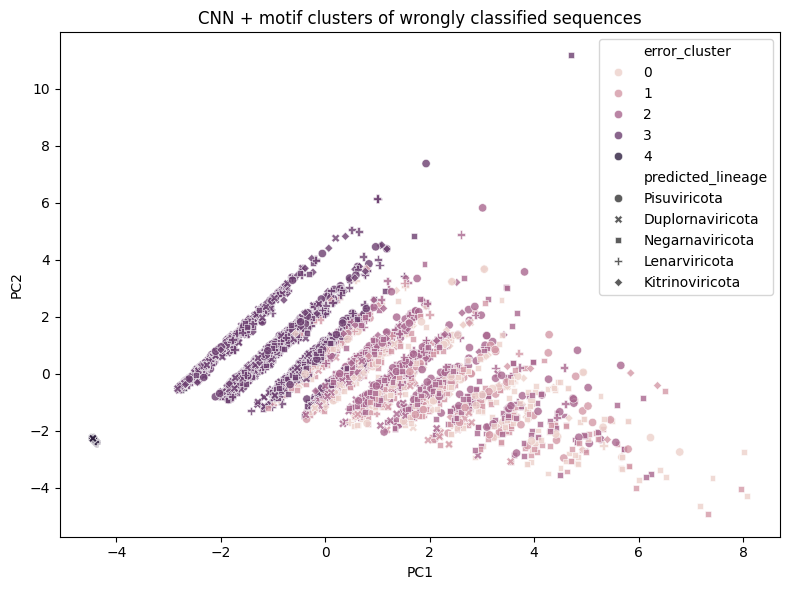

In [76]:
pca = PCA(n_components=2, random_state=42)
X_wrong_pca = pca.fit_transform(X_wrong_scaled)

cnn_motif_wrong_df["PC1"] = X_wrong_pca[:, 0]
cnn_motif_wrong_df["PC2"] = X_wrong_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=cnn_motif_wrong_df,
    x="PC1",
    y="PC2",
    hue="error_cluster",
    style="predicted_lineage",
    alpha=0.8
)

plt.title("CNN + motif clusters of wrongly classified sequences")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(
    "cnn_plus_motif_wrong_sequences_clusters.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Correct predictions: 3013
true_lineage
Lenarviricota       1146
Negarnaviricota      834
Duplornaviricota     431
Pisuviricota         347
Kitrinoviricota      255
Name: count, dtype: int64


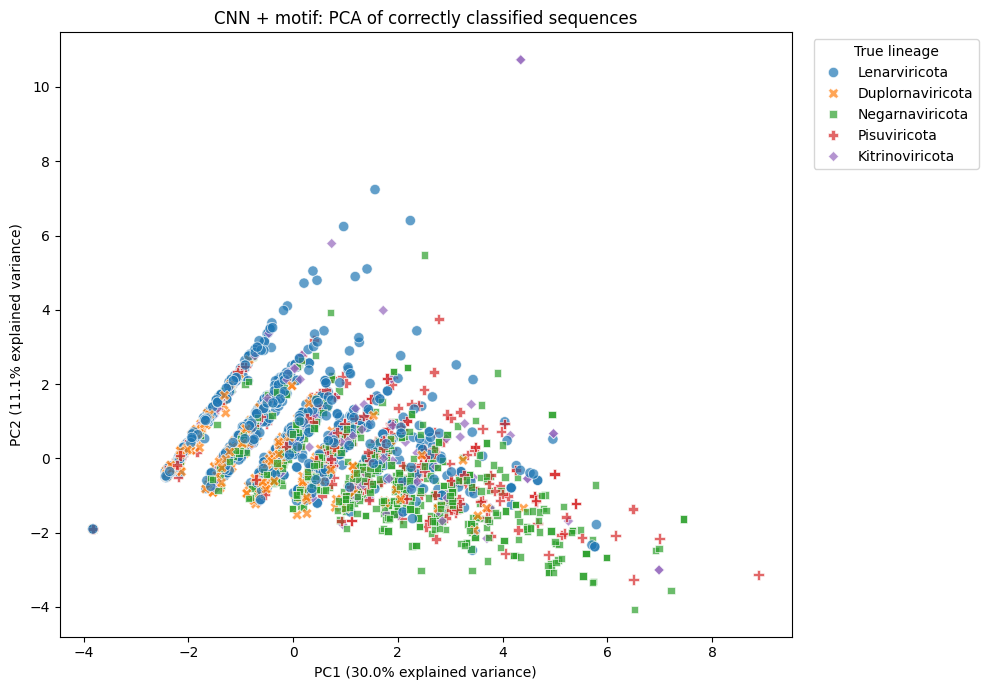

                              PC1_loading   PC2_loading
hairpin_region_1             2.450786e-01 -1.584422e-01
hairpin_region_2             2.232175e-01 -1.478101e-02
hairpin_region_3             2.139766e-01 -1.098020e-01
hairpin_region_4             2.258591e-01 -1.003352e-01
hairpin_region_5             2.011330e-01 -8.136463e-02
bulgeloop_region_1           2.005346e-01 -1.787218e-01
bulgeloop_region_2           1.660548e-01  1.767350e-02
bulgeloop_region_3           1.698594e-01 -1.440957e-01
bulgeloop_region_4           1.377726e-01 -7.439051e-02
bulgeloop_region_5           1.342136e-01 -7.670147e-02
repetitive_hairpin_region_1  0.000000e+00 -1.084202e-19
repetitive_hairpin_region_2 -3.231174e-27 -5.421011e-20
repetitive_hairpin_region_3  0.000000e+00  0.000000e+00
repetitive_hairpin_region_4  0.000000e+00  0.000000e+00
repetitive_hairpin_region_5  0.000000e+00  3.308722e-24
total_motif_count            4.525720e-01 -2.117123e-01
mean_paired_length           2.407708e-01  6.159

In [77]:
# Combine predictions from all seeds
cnn_motif_predictions_df = pd.concat(
    prediction_outputs,
    ignore_index=True
)

# Add regex-derived motif-context features per sequence
positive_motif_features_df = pd.DataFrame(
    list(
        cnn_motif_predictions_df["fold"].apply(
            motif_context_vector_regex
        )
    )
)

cnn_motif_predictions_with_features_df = pd.concat(
    [
        cnn_motif_predictions_df.reset_index(drop=True),
        positive_motif_features_df.reset_index(drop=True)
    ],
    axis=1
)

# Keep only correctly classified sequences
positive_df = cnn_motif_predictions_with_features_df[
    cnn_motif_predictions_with_features_df["correct"] == 1
].copy()

print("Correct predictions:", len(positive_df))
print(positive_df["true_lineage"].value_counts())

feature_cols = [
    col for col in positive_df.columns
    if (
        "region" in col
        or col in [
            "total_motif_count",
            "mean_paired_length",
            "max_paired_length",
            "mean_motif_length",
            "motif_transition_count"
        ]
    )
]

X_positive = positive_df[feature_cols].fillna(0).values

scaler_positive = StandardScaler()
X_positive_scaled = scaler_positive.fit_transform(X_positive)

pca_positive = PCA(
    n_components=2,
    random_state=42
)

X_positive_pca = pca_positive.fit_transform(
    X_positive_scaled
)

positive_df["PC1"] = X_positive_pca[:, 0]
positive_df["PC2"] = X_positive_pca[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=positive_df,
    x="PC1",
    y="PC2",
    hue="true_lineage",
    style="true_lineage",
    alpha=0.7,
    s=55
)

plt.xlabel(
    f"PC1 ({pca_positive.explained_variance_ratio_[0] * 100:.1f}% explained variance)"
)

plt.ylabel(
    f"PC2 ({pca_positive.explained_variance_ratio_[1] * 100:.1f}% explained variance)"
)

plt.title(
    "CNN + motif: PCA of correctly classified sequences"
)

plt.legend(
    title="True lineage",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "cnn_plus_motif_correct_sequences_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

positive_df.to_csv(
    "cnn_plus_motif_correct_sequences_pca.csv",
    index=False
)

positive_pca_loadings_df = pd.DataFrame(
    pca_positive.components_.T,
    index=feature_cols,
    columns=["PC1_loading", "PC2_loading"]
)

positive_pca_variance_df = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio":
        pca_positive.explained_variance_ratio_
})

print(positive_pca_loadings_df)
print(positive_pca_variance_df)

positive_pca_loadings_df.to_csv(
    "cnn_plus_motif_correct_sequences_pca_loadings.csv"
)

positive_pca_variance_df.to_csv(
    "cnn_plus_motif_correct_sequences_pca_variance.csv",
    index=False
)

In [ ]:
def create_prediction_pca(
    prediction_list,
    correct_value,
    model_name,
    output_prefix,
    add_clusters=False,
    n_clusters=5
):

    # Combine prediction results from all seeds

    predictions_df = pd.concat(
        prediction_list,
        ignore_index=True
    )

    # Calculate motif-context features per sequence

    motif_features_df = pd.DataFrame(
        list(
            predictions_df["fold"].apply(
                motif_context_vector_regex
            )
        )
    )

    predictions_with_features_df = pd.concat(
        [
            predictions_df.reset_index(drop=True),
            motif_features_df.reset_index(drop=True)
        ],
        axis=1
    )

    # Select correct or wrong predictions

    subset_df = predictions_with_features_df[
        predictions_with_features_df["correct"] == correct_value
    ].copy()

    classification_name = (
        "correctly classified"
        if correct_value == 1
        else "wrongly classified"
    )

    print(
        f"\n{model_name}: {classification_name} sequences:",
        len(subset_df)
    )

    print("\nSequences per true lineage:")
    print(
        subset_df["true_lineage"]
        .value_counts()
    )

    # Select the same structural features everywhere
  
    requested_feature_cols = [
        col for col in subset_df.columns
        if (
            col.startswith("hairpin_region_")
            or col.startswith("bulgeloop_region_")
            or col.startswith("repetitive_hairpin_region_")
            or col in [
                "total_motif_count",
                "mean_paired_length",
                "max_paired_length",
                "mean_motif_length",
                "motif_transition_count"
            ]
        )
    ]

    # Remove zero-variance columns

    zero_variance_cols = [
        col for col in requested_feature_cols
        if subset_df[col].nunique(dropna=False) <= 1
    ]

    feature_cols = [
        col for col in requested_feature_cols
        if col not in zero_variance_cols
    ]

    print("\nRemoved zero-variance features:")
    print(zero_variance_cols)

    print("\nFeatures used for PCA:")
    print(feature_cols)

    if len(feature_cols) < 2:
        raise ValueError(
            "Fewer than two non-constant features remain for PCA."
        )

    # Standardize features

    X_subset = (
        subset_df[feature_cols]
        .fillna(0)
        .values
    )

    scaler = StandardScaler()

    X_subset_scaled = scaler.fit_transform(
        X_subset
    )


    # Fit PCA

    pca = PCA(
        n_components=2,
        random_state=42
    )

    X_subset_pca = pca.fit_transform(
        X_subset_scaled
    )

    subset_df["PC1"] = X_subset_pca[:, 0]
    subset_df["PC2"] = X_subset_pca[:, 1]

    # Optionally cluster in original standardized space

    if add_clusters:
        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=42,
            n_init=20
        )

        subset_df["pca_cluster"] = kmeans.fit_predict(
            X_subset_scaled
        )


    # PCA loadings

    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=feature_cols,
        columns=[
            "PC1_loading",
            "PC2_loading"
        ]
    )


    # Explained variance

    variance_df = pd.DataFrame({
        "component": ["PC1", "PC2"],
        "explained_variance_ratio":
            pca.explained_variance_ratio_
    })

    print("\nExplained variance:")
    print(variance_df)

    print("\nLargest absolute PC1 loadings:")
    print(
        loadings_df.loc[
            loadings_df["PC1_loading"]
            .abs()
            .sort_values(ascending=False)
            .index
        ].head(10)
    )

    print("\nLargest absolute PC2 loadings:")
    print(
        loadings_df.loc[
            loadings_df["PC2_loading"]
            .abs()
            .sort_values(ascending=False)
            .index
        ].head(10)
    )

    # Plot
    plt.figure(figsize=(10, 7))

    if add_clusters:
        sns.scatterplot(
            data=subset_df,
            x="PC1",
            y="PC2",
            hue="pca_cluster",
            style="true_lineage",
            palette="tab10",
            alpha=0.70,
            s=55
        )

        legend_title = "Cluster / true lineage"

    else:
        sns.scatterplot(
            data=subset_df,
            x="PC1",
            y="PC2",
            hue="true_lineage",
            style="true_lineage",
            alpha=0.70,
            s=55
        )

        legend_title = "True lineage"

    pc1_variance = (
        pca.explained_variance_ratio_[0] * 100
    )

    pc2_variance = (
        pca.explained_variance_ratio_[1] * 100
    )

    plt.xlabel(
        f"PC1 ({pc1_variance:.1f}% explained variance)"
    )

    plt.ylabel(
        f"PC2 ({pc2_variance:.1f}% explained variance)"
    )

    plt.title(
        f"{model_name}: PCA of {classification_name} sequences"
    )

    plt.legend(
        title=legend_title,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{output_prefix}_pca.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # Save outputs

    subset_df.to_csv(
        f"{output_prefix}_pca_sequences.csv",
        index=False
    )

    loadings_df.to_csv(
        f"{output_prefix}_pca_loadings.csv"
    )

    variance_df.to_csv(
        f"{output_prefix}_pca_variance.csv",
        index=False
    )

    return {
        "data": subset_df,
        "loadings": loadings_df,
        "variance": variance_df,
        "scaler": scaler,
        "pca": pca,
        "feature_cols": feature_cols
    }


CNN + motif: correctly classified sequences: 3013

Sequences per true lineage:
true_lineage
Lenarviricota       1146
Negarnaviricota      834
Duplornaviricota     431
Pisuviricota         347
Kitrinoviricota      255
Name: count, dtype: int64

Removed zero-variance features:
['repetitive_hairpin_region_1', 'repetitive_hairpin_region_2', 'repetitive_hairpin_region_3', 'repetitive_hairpin_region_4', 'repetitive_hairpin_region_5']

Features used for PCA:
['hairpin_region_1', 'hairpin_region_2', 'hairpin_region_3', 'hairpin_region_4', 'hairpin_region_5', 'bulgeloop_region_1', 'bulgeloop_region_2', 'bulgeloop_region_3', 'bulgeloop_region_4', 'bulgeloop_region_5', 'total_motif_count', 'mean_paired_length', 'max_paired_length', 'mean_motif_length', 'motif_transition_count']

Explained variance:
  component  explained_variance_ratio
0       PC1                  0.299660
1       PC2                  0.110823

Largest absolute PC1 loadings:
                        PC1_loading  PC2_loading
total

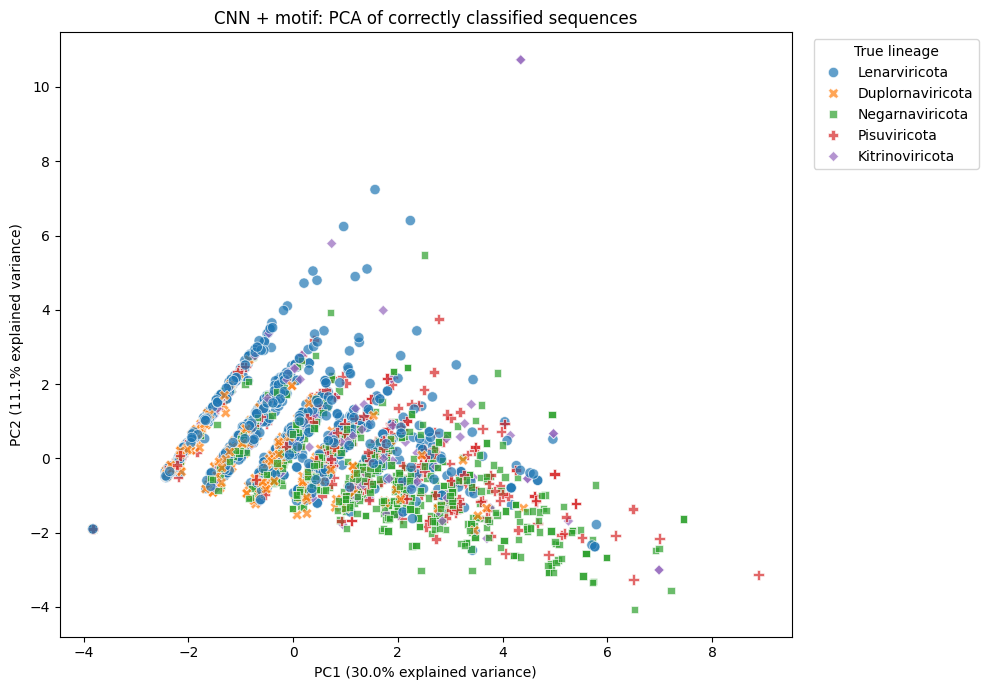

In [79]:
cnn_motif_correct_pca = create_prediction_pca(
    prediction_list=prediction_outputs,
    correct_value=1,
    model_name="CNN + motif",
    output_prefix="cnn_plus_motif_correct",
    add_clusters=False
)

cnn_motif_correct_df = cnn_motif_correct_pca["data"]

cnn_motif_correct_loadings = (
    cnn_motif_correct_pca["loadings"]
)

cnn_motif_correct_variance = (
    cnn_motif_correct_pca["variance"]
)




CNN + motif: wrongly classified sequences: 4463

Sequences per true lineage:
true_lineage
Kitrinoviricota     1239
Pisuviricota        1148
Duplornaviricota    1065
Negarnaviricota      663
Lenarviricota        348
Name: count, dtype: int64

Removed zero-variance features:
['repetitive_hairpin_region_1', 'repetitive_hairpin_region_2', 'repetitive_hairpin_region_3', 'repetitive_hairpin_region_4', 'repetitive_hairpin_region_5']

Features used for PCA:
['hairpin_region_1', 'hairpin_region_2', 'hairpin_region_3', 'hairpin_region_4', 'hairpin_region_5', 'bulgeloop_region_1', 'bulgeloop_region_2', 'bulgeloop_region_3', 'bulgeloop_region_4', 'bulgeloop_region_5', 'total_motif_count', 'mean_paired_length', 'max_paired_length', 'mean_motif_length', 'motif_transition_count']

Explained variance:
  component  explained_variance_ratio
0       PC1                  0.292827
1       PC2                  0.118320

Largest absolute PC1 loadings:
                        PC1_loading  PC2_loading
total_m

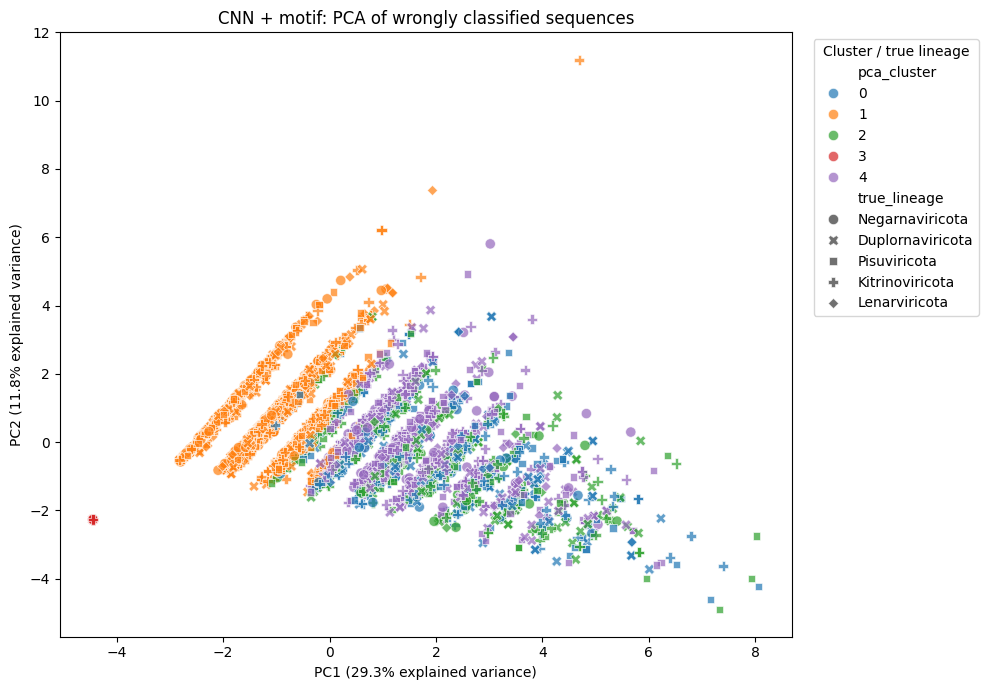

In [80]:
cnn_motif_wrong_pca = create_prediction_pca(
    prediction_list=prediction_outputs,
    correct_value=0,
    model_name="CNN + motif",
    output_prefix="cnn_plus_motif_wrong",
    add_clusters=True,
    n_clusters=5
)

cnn_motif_wrong_df = cnn_motif_wrong_pca["data"]

cnn_motif_wrong_df["pca_cluster"]

cnn_motif_wrong_df = cnn_motif_wrong_df.rename(
    columns={"pca_cluster": "error_cluster"}
)

In [ ]:
def plot_top_pca_loadings(
    loadings_df,
    output_prefix,
    model_name,
    classification_name,
    top_n=10
):

    required_columns = {
        "PC1_loading",
        "PC2_loading"
    }

    missing_columns = required_columns.difference(
        loadings_df.columns
    )

    if missing_columns:
        raise ValueError(
            f"Missing loading columns: {missing_columns}"
        )

    # Make sure feature names are available as a column
    loading_plot_df = (
        loadings_df
        .reset_index()
        .rename(columns={"index": "feature"})
    )

    for component in ["PC1", "PC2"]:

        loading_column = f"{component}_loading"

        # Select largest features by absolute loading
        top_loadings = (
            loading_plot_df
            .assign(
                absolute_loading=lambda df:
                    df[loading_column].abs()
            )
            .sort_values(
                "absolute_loading",
                ascending=False
            )
            .head(top_n)
            .sort_values(
                loading_column,
                ascending=True
            )
        )

        print(
            f"\n{model_name}, {classification_name}: "
            f"largest {component} loadings"
        )

        print(
            top_loadings[
                [
                    "feature",
                    loading_column,
                    "absolute_loading"
                ]
            ]
        )

        # Save selected loadings
        top_loadings.to_csv(
            f"{output_prefix}_{component.lower()}_top_loadings.csv",
            index=False
        )

        # Plot signed loadings
        plt.figure(figsize=(9, 6))

        sns.barplot(
            data=top_loadings,
            x=loading_column,
            y="feature",
            orient="h"
        )

        plt.axvline(
            0,
            color="black",
            linewidth=1
        )

        plt.xlabel(f"{component} loading")
        plt.ylabel("Motif-context feature")

        plt.title(
            f"{model_name}: largest {component} loadings\n"
            f"{classification_name} sequences"
        )

        plt.tight_layout()

        plt.savefig(
            f"{output_prefix}_{component.lower()}_top_loadings.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()


CNN + motif, correctly classified: largest PC1 loadings
                   feature  PC1_loading  absolute_loading
4         hairpin_region_5     0.201133          0.201133
2         hairpin_region_3     0.213977          0.213977
1         hairpin_region_2     0.223217          0.223217
3         hairpin_region_4     0.225859          0.225859
13       mean_motif_length     0.237787          0.237787
11      mean_paired_length     0.240771          0.240771
0         hairpin_region_1     0.245079          0.245079
12       max_paired_length     0.326470          0.326470
14  motif_transition_count     0.439665          0.439665
10       total_motif_count     0.452572          0.452572


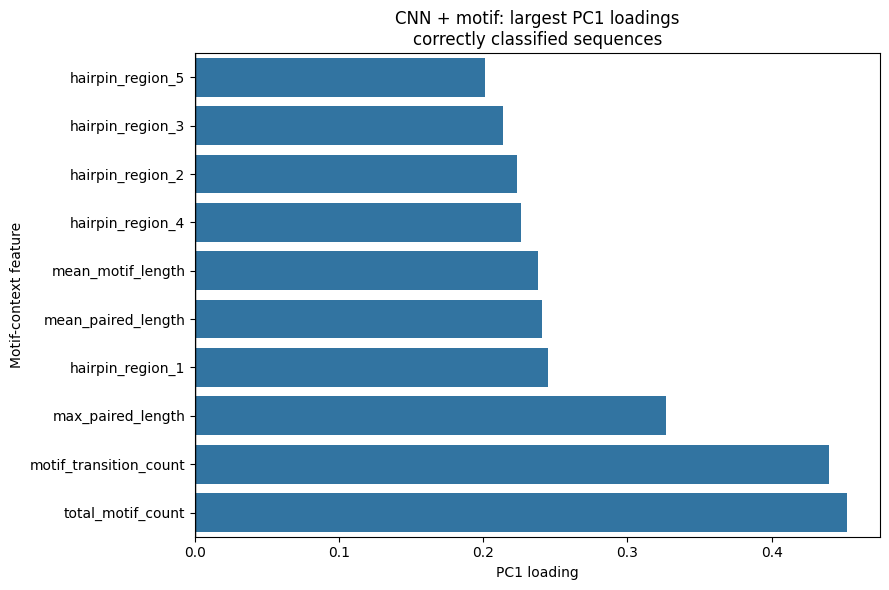


CNN + motif, correctly classified: largest PC2 loadings
                   feature  PC2_loading  absolute_loading
14  motif_transition_count    -0.272037          0.272037
10       total_motif_count    -0.211712          0.211712
5       bulgeloop_region_1    -0.178722          0.178722
0         hairpin_region_1    -0.158442          0.158442
7       bulgeloop_region_3    -0.144096          0.144096
2         hairpin_region_3    -0.109802          0.109802
3         hairpin_region_4    -0.100335          0.100335
13       mean_motif_length     0.390271          0.390271
12       max_paired_length     0.480548          0.480548
11      mean_paired_length     0.615983          0.615983


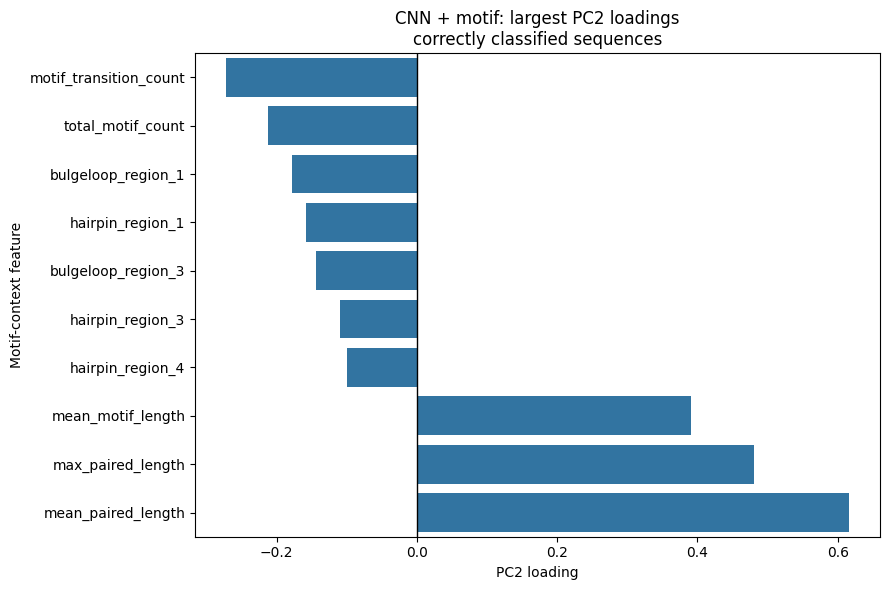


CNN + motif, wrongly classified: largest PC1 loadings
                   feature  PC1_loading  absolute_loading
5       bulgeloop_region_1     0.195748          0.195748
1         hairpin_region_2     0.195963          0.195963
2         hairpin_region_3     0.196179          0.196179
3         hairpin_region_4     0.205231          0.205231
0         hairpin_region_1     0.219912          0.219912
11      mean_paired_length     0.262423          0.262423
13       mean_motif_length     0.285094          0.285094
12       max_paired_length     0.336959          0.336959
14  motif_transition_count     0.436688          0.436688
10       total_motif_count     0.449759          0.449759


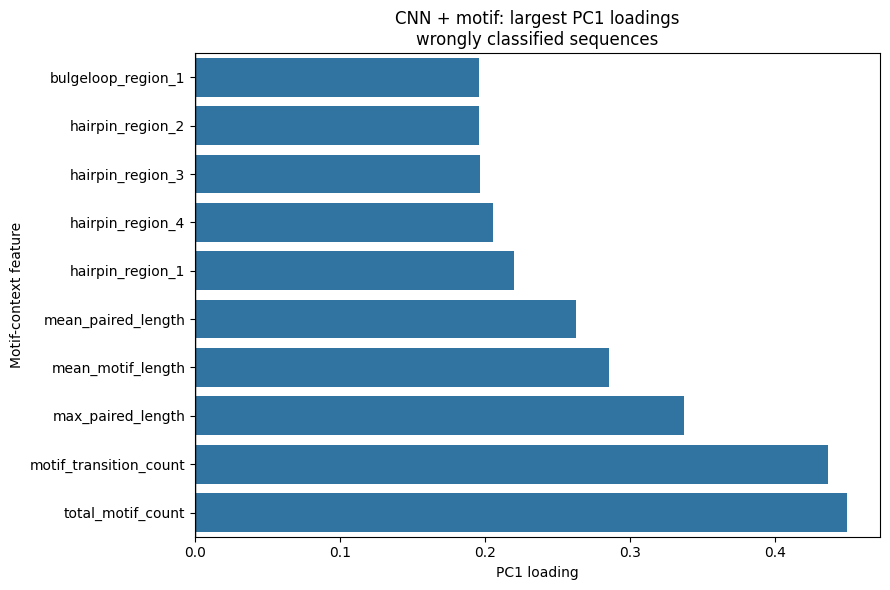


CNN + motif, wrongly classified: largest PC2 loadings
                   feature  PC2_loading  absolute_loading
14  motif_transition_count    -0.297390          0.297390
10       total_motif_count    -0.245709          0.245709
3         hairpin_region_4    -0.129392          0.129392
8       bulgeloop_region_4    -0.120182          0.120182
5       bulgeloop_region_1    -0.107833          0.107833
4         hairpin_region_5    -0.105788          0.105788
6       bulgeloop_region_2    -0.100703          0.100703
13       mean_motif_length     0.439862          0.439862
12       max_paired_length     0.446532          0.446532
11      mean_paired_length     0.591492          0.591492


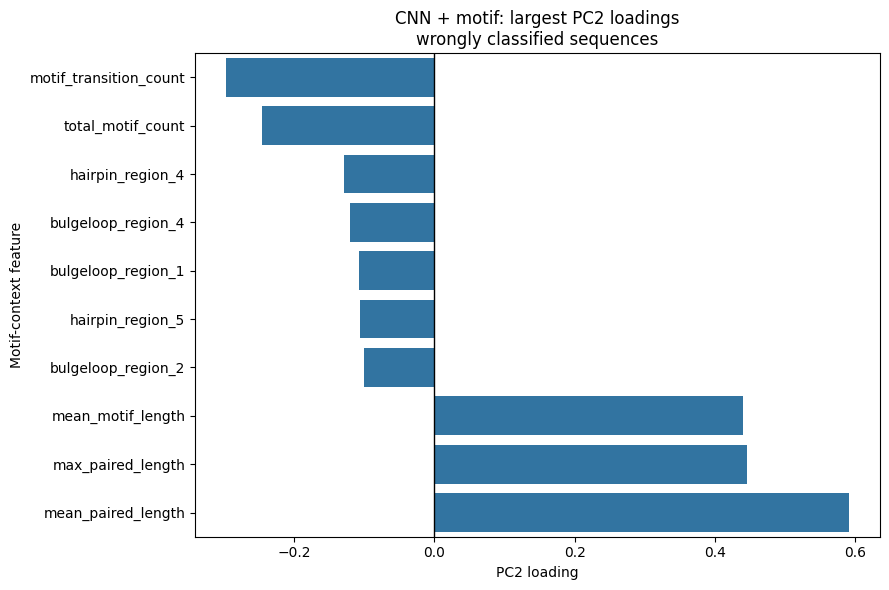

In [82]:
plot_top_pca_loadings(
    loadings_df=cnn_motif_correct_pca["loadings"],
    output_prefix="cnn_plus_motif_correct",
    model_name="CNN + motif",
    classification_name="correctly classified",
    top_n=10
)

plot_top_pca_loadings(
    loadings_df=cnn_motif_wrong_pca["loadings"],
    output_prefix="cnn_plus_motif_wrong",
    model_name="CNN + motif",
    classification_name="wrongly classified",
    top_n=10
)

In [83]:
def plot_multiclass_roc(
    prediction_outputs,
    classes,
    model_name,
    output_filename
):
    """
    Plot one-vs-rest ROC curves using predictions pooled across seeds.
    """

    predictions_df = pd.concat(
        prediction_outputs,
        ignore_index=True
    )

    classes = np.asarray(classes)
    n_classes = len(classes)

    probability_columns = [
        f"prob_{class_name}"
        for class_name in classes
    ]

    missing_columns = [
        column
        for column in probability_columns
        if column not in predictions_df.columns
    ]

    if missing_columns:
        raise ValueError(
            "Missing probability columns: "
            f"{missing_columns}. Rerun the prediction loop after "
            "saving every class probability."
        )

    y_true = predictions_df["y_true"].to_numpy()

    y_score = predictions_df[
        probability_columns
    ].to_numpy()

    # Convert multiclass labels into binary one-vs-rest columns
    y_true_binary = label_binarize(
        y_true,
        classes=np.arange(n_classes)
    )

    fpr = {}
    tpr = {}
    roc_auc = {}

    # ROC curve for each lineage
    for class_index, class_name in enumerate(classes):

        fpr[class_name], tpr[class_name], _ = roc_curve(
            y_true_binary[:, class_index],
            y_score[:, class_index]
        )

        roc_auc[class_name] = auc(
            fpr[class_name],
            tpr[class_name]
        )

    # Micro-average ROC
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true_binary.ravel(),
        y_score.ravel()
    )

    roc_auc["micro"] = auc(
        fpr["micro"],
        tpr["micro"]
    )

    # Macro-average ROC curve
    all_fpr = np.unique(
        np.concatenate([
            fpr[class_name]
            for class_name in classes
        ])
    )

    mean_tpr = np.zeros_like(all_fpr)

    for class_name in classes:
        mean_tpr += np.interp(
            all_fpr,
            fpr[class_name],
            tpr[class_name]
        )

    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr

    roc_auc["macro"] = auc(
        fpr["macro"],
        tpr["macro"]
    )

    # Plot
    plt.figure(figsize=(10, 8))

    for class_name in classes:
        plt.plot(
            fpr[class_name],
            tpr[class_name],
            linewidth=2,
            label=(
                f"{class_name} "
                f"(AUC = {roc_auc[class_name]:.3f})"
            )
        )

    plt.plot(
        fpr["macro"],
        tpr["macro"],
        linestyle="--",
        linewidth=3,
        label=(
            "Macro-average "
            f"(AUC = {roc_auc['macro']:.3f})"
        )
    )

    plt.plot(
        fpr["micro"],
        tpr["micro"],
        linestyle=":",
        linewidth=3,
        label=(
            "Micro-average "
            f"(AUC = {roc_auc['micro']:.3f})"
        )
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Chance"
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1.02)

    plt.xlabel("False-positive rate")
    plt.ylabel("True-positive rate")
    plt.title(f"One-vs-rest ROC curves: {model_name}")

    plt.legend(
        loc="lower right",
        fontsize=8
    )

    plt.tight_layout()

    plt.savefig(
        output_filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    auc_df = pd.DataFrame({
        "lineage": list(classes)
            + ["macro_average", "micro_average"],
        "roc_auc": [
            roc_auc[class_name]
            for class_name in classes
        ] + [
            roc_auc["macro"],
            roc_auc["micro"]
        ]
    })

    print(auc_df)

    return auc_df

In [84]:
def calculate_auc_by_seed(
    prediction_outputs,
    classes,
    model_name
):
    classes = np.asarray(classes)

    probability_columns = [
        f"prob_{class_name}"
        for class_name in classes
    ]

    auc_rows = []

    for seed_df in prediction_outputs:

        seed = seed_df["seed"].iloc[0]

        y_true = seed_df["y_true"].to_numpy()

        y_true_binary = label_binarize(
            y_true,
            classes=np.arange(len(classes))
        )

        y_score = seed_df[
            probability_columns
        ].to_numpy()

        macro_auc = roc_auc_score(
            y_true_binary,
            y_score,
            average="macro",
            multi_class="ovr"
        )

        weighted_auc = roc_auc_score(
            y_true_binary,
            y_score,
            average="weighted",
            multi_class="ovr"
        )

        micro_auc = roc_auc_score(
            y_true_binary,
            y_score,
            average="micro",
            multi_class="ovr"
        )

        auc_rows.append({
            "model": model_name,
            "seed": seed,
            "macro_auc": macro_auc,
            "weighted_auc": weighted_auc,
            "micro_auc": micro_auc
        })

    return pd.DataFrame(auc_rows)

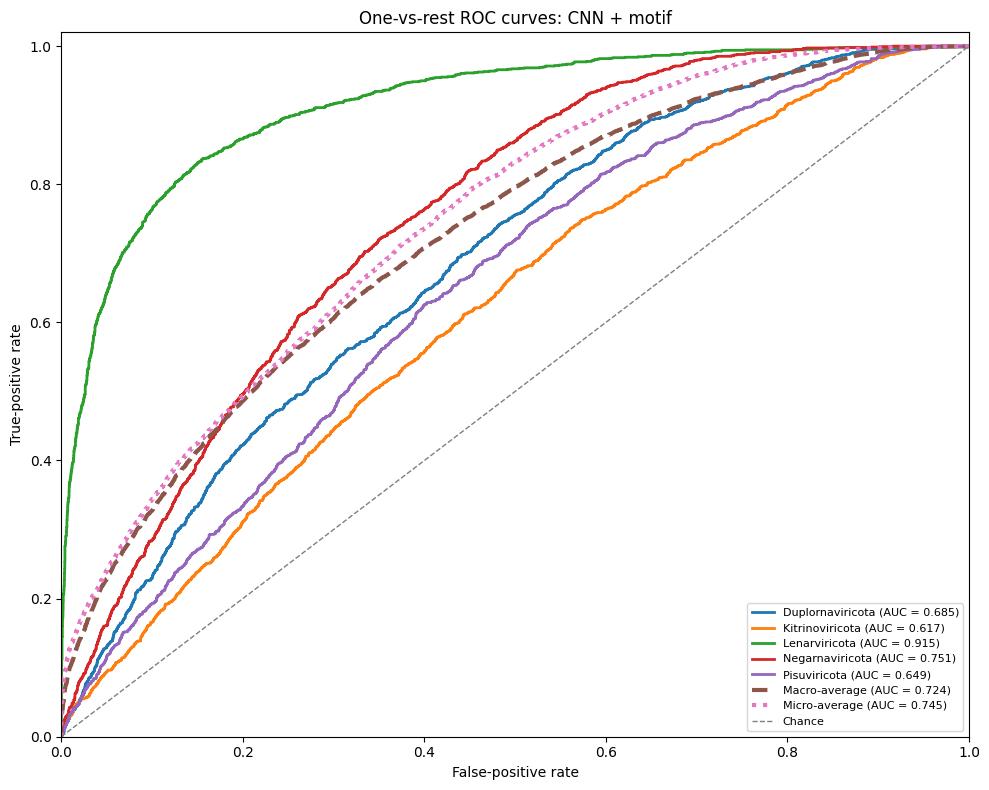

            lineage   roc_auc
0  Duplornaviricota  0.684888
1   Kitrinoviricota  0.616533
2     Lenarviricota  0.915342
3   Negarnaviricota  0.751252
4      Pisuviricota  0.649032
5     macro_average  0.723503
6     micro_average  0.744763


In [85]:
cnn_motif_auc_df = plot_multiclass_roc(
    prediction_outputs=prediction_outputs,
    classes=le.classes_,
    model_name="CNN + motif",
    output_filename="cnn_plus_motif_multiclass_roc.png"
)